# Part 1: Clustering and Dimensionality Reduction

In [ ]:
# Basic packages
import numpy as np
from functools import reduce

# Data handling
import pandas as pd
import polars as pl  

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from yellowbrick.cluster.elbow import kelbow_visualizer
import matplotlib.cm as cm
from sklearn.decomposition import PCA

# Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from IPython.display import Image
from tqdm import tqdm
%matplotlib inline

In [ ]:
# Import data 

demo_data = pl.read_csv("DemoStats.csv")

housespend_data = pl.read_csv("HouseholdSpend.csv")

demo_metadata = pl.read_csv("DemoStats 2024 - Metadata.csv")

housespend_metadata = pl.read_csv("HouseholdSpend 2024 - Metadata.csv")

In [ ]:
# Check how many variables in each dataset

print(demo_data.shape) # 736 variables
print(housespend_data.shape) # 246 variables


(868970, 736)
(868970, 246)


In [ ]:
# # Selecting the highest hierarchy variables. 

demo_data = demo_data.select(["CODE",
    "ECYBAS12P", "ECYBAS15P", "ECYBAS18P", "ECYBAS19P", "ECYBASTNGH", "ECYBASADUH",
    "ECYBASCF", "ECYBASCFH", "ECYBASKID", "ECYBASLF", "ECYPTAAVG", "ECYPMAPOP",
    "ECYPMAAVG", "ECYPFAPOP", "ECYPFAAVG", "ECYHTAHPOP", "ECYHTAAVG", "ECYHMAHPOP",
    "ECYHMAAVG", "ECYHFAHPOP", "ECYHFAAVG", "ECYMTNHHD", "ECYMTNAVG", "ECYHSZ1PER",
    "ECYHSZ2PER", "ECYHSZ3PER", "ECYHSZ4PER", "ECYHSZ5PER", "ECYHSZTPER", "ECYHSZAVG",
    "ECYHTYFHT", "ECYHTYNFH", "ECYMARMCL", "ECYMARNMCL", "ECYCFSC", "ECYCFSLP",
    "ECYCFSNFP", "ECYHFSC", "ECYHFSLP", "ECYHFSWC", "ECYCHAKIDS", "ECYCHACFCH",
    "ECYCHAFHCH", "ECYCHAHHCH",
    'ECYMOBNMOV', 'ECYMOBMOV', 'ECYTENOWN', 'ECYTENRENT', 'ECYTENBAND',
    'ECYSTYHOUS', 'ECYSTYAPT', 'ECYSTYOTHR', 'ECYCDOCO', 'ECYCDONC',
    'ECYCDOBAND', 'ECYHRIAVG', 'ECYHRIAGG', 'ECYHNIAVG', 'ECYHNIAGG',
    'ECYPNIHP15', 'ECYPNIAVG', 'ECYEDUNCDD', 'ECYEDUHSCE', 'ECYEDUATCD',
    'ECYEDUCOLL', 'ECYEDUUDBB', 'ECYEDUUD', 'ECYEDANCDD', 'ECYEDAHSCE',
    'ECYEDAATCD', 'ECYEDACOLL', 'ECYEDAUDBB', 'ECYEDAUD', 'ECYEDAUDBD',
    'ECYACTINLF', 'ECYACTNOLF', 'ECYACTPR', 'ECYACTER', 'ECYACTUR',
    'ECYCWT', 'ECYOCCINLF', 'ECYINDINLF', 'ECYPOWINLF', 'ECYTRAALL',
    'ECYRELBUDD', 'ECYRELCHR', 'ECYRELHIND', 'ECYRELJEWI', 'ECYRELMUSL',
    'ECYRELSIKH', 'ECYRELOREL', 'ECYRELNREL', 'ECYVISVM', 'ECYVISNVM',
    'ECYAIDABO', 'ECYAIDNABO', 'ECYKNOENGL', 'ECYKNOFREN', 'ECYKNOENFR',
    'ECYKNONEF', 'ECYMOTENGL', 'ECYMOTFREN', 'ECYMOTNOFF', 'ECYMOTMULT',
    'ECYHOMENGL', 'ECYHOMFREN', 'ECYHOMNOFF', 'ECYHOMMULT', 'ECYTIMNI',
    'ECYTIMIMGT', 'ECYTIMNPER', 'ECYRIMRIM', 'ECYPIMNI', 'ECYPIMIM',
    'ECYPIMNPER', 'ECYAIMNI', 'ECYAIMIM', 'ECYAIMNPER', 'ECYGEN1GEN',
    'ECYGEN2GEN', 'ECYGEN3GEN', 'ECYTCACIT', 'ECYNCANCIT'
]
)

housespend_data = housespend_data.select(["CODE", "HSTX001", "HSTC001", "HSSH001S", "HSFD001S", "HSHO001S", "HSHC001S", "HSHF001S", "HSTR001S", "HSRE001S", "HSPC001S", "HSCL001S", "HSED002S", "HSRO001S", "HSTA001S", "HSGC001S", "HSME001S", "HSMG001S", "HSTE001ZBS"])

In [ ]:
# Merge both datasets together

# Perform an inner join to find the intersection based on postal_code
df_intersection = demo_data.join(housespend_data, on="CODE", how="inner")

# Display result
df_intersection.describe()

statistic,CODE,ECYBAS12P,ECYBAS15P,ECYBAS18P,ECYBAS19P,ECYBASTNGH,ECYBASADUH,ECYBASCF,ECYBASCFH,ECYBASKID,ECYBASLF,ECYPTAAVG,ECYPMAPOP,ECYPMAAVG,ECYPFAPOP,ECYPFAAVG,ECYHTAHPOP,ECYHTAAVG,ECYHMAHPOP,ECYHMAAVG,ECYHFAHPOP,ECYHFAAVG,ECYMTNHHD,ECYMTNAVG,ECYHSZ1PER,ECYHSZ2PER,ECYHSZ3PER,ECYHSZ4PER,ECYHSZ5PER,ECYHSZTPER,ECYHSZAVG,ECYHTYFHT,ECYHTYNFH,ECYMARMCL,ECYMARNMCL,ECYCFSC,…,ECYHOMENGL,ECYHOMFREN,ECYHOMNOFF,ECYHOMMULT,ECYTIMNI,ECYTIMIMGT,ECYTIMNPER,ECYRIMRIM,ECYPIMNI,ECYPIMIM,ECYPIMNPER,ECYAIMNI,ECYAIMIM,ECYAIMNPER,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCACIT,ECYNCANCIT,HSTX001,HSTC001,HSSH001S,HSFD001S,HSHO001S,HSHC001S,HSHF001S,HSTR001S,HSRE001S,HSPC001S,HSCL001S,HSED002S,HSRO001S,HSTA001S,HSGC001S,HSME001S,HSMG001S,HSTE001ZBS
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""868970""",868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,…,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,41.254934,39.613594,37.819792,37.323999,3.072744,24.49923,12.76093,12.051364,12.740845,24.633679,37.813783,23.252432,36.944927,23.431766,36.743373,45.881762,37.145647,22.905504,36.365544,22.976258,35.957577,18.432629,48.137206,5.421176,6.289593,2.691611,2.456448,1.573801,45.881762,2.453922,12.051364,6.381265,21.893216,16.939256,10.565132,…,29.485802,8.369809,6.013198,2.012953,31.717238,11.757474,2.407051,1.635501,31.717238,11.757474,2.407051,31.717238,11.757474,2.407051,14.168175,7.448384,24.265204,40.528679,5.353084,421335.834661,1.6065e6,388812.651163,278016.994627,111401.557243,109343.827301,76103.411113,271135.371662,87929.804561,45315.650319,70798.452452,34398.504565,3570.867859,70468.350013,25849.158365,33310.372386,48732.91062,209040.481816
"""std""",null,152.539099,145.876662,139.320601,137.611402,12.468123,87.647782,50.126862,47.828225,49.02113,89.352097,14.787466,90.565636,15.470914,86.964102,19.196496,171.817976,14.607243,89.090419,15.345463,85.289319,18.946913,69.379951,19.575604,21.554341,26.842601,9.560087,9.085401,6.696364,171.817976,1.16391,47.828225,23.778917,86.59306,57.697026,42.799455,…,135.183146,78.48685,21.283143,6.407186,149.721097,32.868441,10.479555,5.761745,149.721097,32.868441,10.479555,149.721097,32.868441,10.479555,40.185434,24.588753,131.818196,163.866165,17.893635,1.5969e6,5.9255e6,1.3661e6,1.0471e6,420881.63654,429642.774397,290959.592849,1.0751e6,327376.60947,163377.943862,249311.269506,114999.916794,14386.745375,264786.580294,94955.831503,127397.296924,206454.726959,1.2713e6
"""min""","""A0A0A0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.4599e7
"""25%""",null,7.0,7.0,6.0,6.0,0.0,4.0,2.0,2.0,2.0,4.0,35.4,5.0,34.3,2.0,31.0,7.0,35.0,5.0,34.1,2.0,30.3,3.0

In [ ]:
# Drop the CODE column because we no longer need it after we merge both datasets

df_intersection = df_intersection.drop("CODE")

In [ ]:

# We also remove rows that has 0 Total Household Population 18 and 19 Years Or Over and Total Population 18 and 19 Years Or Over as this is not normal for a household

df_intersection= df_intersection.filter((pl.col("ECYBAS18P") != 0) & (pl.col("ECYBAS19P") != 0))

# Since we do not have any data of household refunds, subsidies, financial adjustments, we believe that it is invalid to have "Total Non-Current Consumption" as negative values, thus we remove them

df_intersection = df_intersection.filter((pl.col("HSTE001ZBS") >= 0))


df_intersection.describe()


statistic,ECYBAS12P,ECYBAS15P,ECYBAS18P,ECYBAS19P,ECYBASTNGH,ECYBASADUH,ECYBASCF,ECYBASCFH,ECYBASKID,ECYBASLF,ECYPTAAVG,ECYPMAPOP,ECYPMAAVG,ECYPFAPOP,ECYPFAAVG,ECYHTAHPOP,ECYHTAAVG,ECYHMAHPOP,ECYHMAAVG,ECYHFAHPOP,ECYHFAAVG,ECYMTNHHD,ECYMTNAVG,ECYHSZ1PER,ECYHSZ2PER,ECYHSZ3PER,ECYHSZ4PER,ECYHSZ5PER,ECYHSZTPER,ECYHSZAVG,ECYHTYFHT,ECYHTYNFH,ECYMARMCL,ECYMARNMCL,ECYCFSC,ECYCFSLP,…,ECYHOMENGL,ECYHOMFREN,ECYHOMNOFF,ECYHOMMULT,ECYTIMNI,ECYTIMIMGT,ECYTIMNPER,ECYRIMRIM,ECYPIMNI,ECYPIMIM,ECYPIMNPER,ECYAIMNI,ECYAIMIM,ECYAIMNPER,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCACIT,ECYNCANCIT,HSTX001,HSTC001,HSSH001S,HSFD001S,HSHO001S,HSHC001S,HSHF001S,HSTR001S,HSRE001S,HSPC001S,HSCL001S,HSED002S,HSRO001S,HSTA001S,HSGC001S,HSME001S,HSMG001S,HSTE001ZBS
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,…,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",45.5266,43.594179,41.496298,40.916616,3.610484,26.690495,14.601034,13.763268,14.794477,27.340712,41.949574,25.901046,41.09709,25.84464,40.716042,50.764869,41.113123,25.469568,40.354772,25.295301,39.768468,19.114778,53.46882,4.53619,6.724087,3.027624,2.949877,1.877001,50.764869,2.794195,13.763268,5.35151,25.406064,17.23606,12.339213,2.261821,…,34.189978,8.611003,5.975052,1.988837,36.989172,11.934656,1.841041,1.620849,36.989172,11.934656,1.841041,36.989172,11.934656,1.841041,13.780167,8.442087,28.542615,46.105128,4.659741,484797.471731,1.8173e6,437915.402075,312897.909282,125359.54916,121696.232906,88825.106912,312317.229184,101491.729428,50319.699025,78636.646345,38543.567546,4044.774232,78519.560426,28944.666535,37769.67165,54976.944093,334788.999573
"""std""",175.296426,167.49885,159.835745,157.860304,14.386625,99.804731,58.033027,55.38514,56.245381,102.356625,7.923153,104.621493,9.799841,99.528298,15.164517,197.421049,8.031392,102.85831,9.905228,97.529778,15.089352,78.567588,11.726076,22.319563,30.819363,10.930411,10.538604,7.568176,197.421049,0.795913,55.38514,24.489374,100.53082,64.342671,49.767244,8.877752,…,156.864741,91.92523,20.610997,6.037,175.238771,31.144145,7.376,5.531209,175.238771,31.144145,7.376,175.238771,31.144145,7.376,36.176816,27.898286,154.489768,190.384869,13.672755,1.7607e6,6.7894e6,1.5548e6,1.2028e6,482495.38443,494164.510116,333584.856007,1.2412e6,375176.206893,186282.283202,283268.558244,127449.570742,16619.715808,301388.814673,107815.069352,145684.831622,224192.007446,1.4741e6
"""min""",1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,13.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",10.0,10.0,9.0,9.0,1.0,6.0,3.0,3.0,2.0,6.0,37.5,7.0,36.5,4.0,35.0,11.0,37.2,7.0,36.3,4.0,34.6,4.0,48.5,0.0,1.0,1.0,1.0,0.0,11.0,

In [ ]:
# Apply Standardization

merge_numeric_columns = df_intersection.select(pl.selectors.numeric()).columns

df_intersection = df_intersection.with_columns([
    ((pl.col(col) - pl.col(col).mean()) / pl.col(col).std()).alias(col)
    for col in merge_numeric_columns
])

df_intersection.describe()

statistic,ECYBAS12P,ECYBAS15P,ECYBAS18P,ECYBAS19P,ECYBASTNGH,ECYBASADUH,ECYBASCF,ECYBASCFH,ECYBASKID,ECYBASLF,ECYPTAAVG,ECYPMAPOP,ECYPMAAVG,ECYPFAPOP,ECYPFAAVG,ECYHTAHPOP,ECYHTAAVG,ECYHMAHPOP,ECYHMAAVG,ECYHFAHPOP,ECYHFAAVG,ECYMTNHHD,ECYMTNAVG,ECYHSZ1PER,ECYHSZ2PER,ECYHSZ3PER,ECYHSZ4PER,ECYHSZ5PER,ECYHSZTPER,ECYHSZAVG,ECYHTYFHT,ECYHTYNFH,ECYMARMCL,ECYMARNMCL,ECYCFSC,ECYCFSLP,…,ECYHOMENGL,ECYHOMFREN,ECYHOMNOFF,ECYHOMMULT,ECYTIMNI,ECYTIMIMGT,ECYTIMNPER,ECYRIMRIM,ECYPIMNI,ECYPIMIM,ECYPIMNPER,ECYAIMNI,ECYAIMIM,ECYAIMNPER,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCACIT,ECYNCANCIT,HSTX001,HSTC001,HSSH001S,HSFD001S,HSHO001S,HSHC001S,HSHF001S,HSTR001S,HSRE001S,HSPC001S,HSCL001S,HSED002S,HSRO001S,HSTA001S,HSGC001S,HSME001S,HSMG001S,HSTE001ZBS
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,…,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.0234e-18,1.4748e-17,-3.4031e-17,-1.0139e-17,1.6248e-17,-6.2325e-18,2.1299e-17,9.1992e-19,2.2015e-17,-1.4109e-17,1.5892e-16,-1.0389e-17,1.0990e-15,-4.4846e-18,8.7117e-17,-2.4706e-17,2.2603e-16,4.8670e-18,1.5786e-16,-1.1361e-17,4.9625e-16,2.4105e-17,2.6227e-16,-1.8893e-17,1.7070e-17,1.4132e-17,-1.0867e-18,9.6649e-18,-2.4706e-17,7.8699e-17,9.1992e-19,2.5755e-17,1.3276e-17,-5.3557e-18,8.3196e-18,-2.8098e-17,…,3.1910e-19,2.0382e-18,7.6411e-18,4.8049e-17,-1.2448e-18,1.1442e-18,-2.5056e-17,4.8526e-17,-1.2448e-18,1.1442e-18,-2.5056e-17,-1.2448e-18,1.1442e-18,-2.5056e-17,9.6592e-19,4.1397e-17,2.0066e-18,8.1413e-18,3.1801e-17,6.7379e-17,-8.1816e-18,3.4313e-17,-2.9164e-17,-7.8510e-18,-6.2747e-17,-3.8407e-18,2.7578e-17,-2.9538e-17,-6.3179e-17,-4.2213e-17,-1.3569e-18,3.7527e-17,-4.6281e-17,4.8903e-17,-2.5531e-17,-2.9650e-17,2.6502e-17
"""std""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,…,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
"""min""",-0.254007,-0.254295,-0.253362,-0.25286,-0.250961,-0.267427,-0.251599,-0.248501,-0.263035,-0.267112,-3.552825,-0.247569,-4.193649,-0.259671,-2.684955,-0.25714,-5.119053,-0.247618,-4.074088,-0.25936,-2.635532,-0.243291,-4.559822,-0.203238,-0.218177,-0.276991,-0.279912,-0.248012,-0.25714,-3.510678,-0.248501,-0.218524,-0.252719,-0.267879,-0.247938,-0.254774,…,-0.217958,-0.093674,-0.289896,-0.329441,-0.211079,-0.383207,-0.249599,-0.293037,-0.211079,-0.383207,-0.249599,-0.211079,-0.383207,-0.249599,-0.380912,-0.302602,-0.184754,-0.242168,-0.340805,-0.275341,-0.267666,-0.281655,-0.260132,-0.259815,-0.246267,-0.266274,-0.25162,-0.270517,-0.270126,-0.277605,-0.302422,-0.243372,-0.260526,-0.268466,-0.259256,-0.245223,-0.227112
"""25%""",-0.202666,-0.200564,-0.203311,-0.202183,-0.181452,-0.20731,-0.199904,-0.194335,-0.22

In [ ]:
# Define function to drop low_variance variables
def drop_low_variance(df: pl.DataFrame, threshold: float = 0.01) -> pl.DataFrame:
    numeric_cols = df.select(pl.selectors.numeric()).columns

    # Compute variance
    variances = df.select([
        pl.col(col).var().alias(col) for col in numeric_cols
    ]).row(0)

    # Keep columns with variance above threshold
    keep_cols = [col for col, var in zip(numeric_cols, variances) if var > threshold]
    return df.select(keep_cols) 

# Define function to drop highly correlated variables
def drop_highly_correlated(df: pl.DataFrame, threshold: float = 0.95) -> pl.DataFrame:
    df_pd = df.to_pandas()

    # Compute correlation matrix
    corr_matrix = df_pd.corr(numeric_only=True).abs()

    # Select upper triangle of correlation matrix
    upper = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_matrix = corr_matrix.where(upper)

    # Find columns to drop
    to_drop = [column for column in upper_matrix.columns if any(upper_matrix[column] > threshold)]

    # Drop from original polars DataFrame
    return df.drop(to_drop)

# Drop low-variance variables
filtered_df = drop_low_variance(df_intersection, threshold=0.01)

# Drop highly correlated variables
final_df = drop_highly_correlated(filtered_df, threshold=0.95)

final_df.describe()

statistic,ECYBAS12P,ECYPTAAVG,ECYPMAAVG,ECYPFAAVG,ECYHTAAVG,ECYHMAAVG,ECYHFAAVG,ECYMTNAVG,ECYHSZ5PER,ECYHSZAVG,ECYHFSWC,ECYCHACFCH,ECYCHAFHCH,ECYCHAHHCH,ECYTENRENT,ECYTENBAND,ECYSTYAPT,ECYSTYOTHR,ECYCDOCO,ECYHRIAVG,ECYPNIAVG,ECYEDUNCDD,ECYEDUATCD,ECYEDUUDBB,ECYEDUUD,ECYACTPR,ECYACTER,ECYACTUR,ECYRELBUDD,ECYRELHIND,ECYRELJEWI,ECYRELMUSL,ECYRELSIKH,ECYRELOREL,ECYVISVM,ECYAIDABO,ECYKNOENGL,ECYKNOFREN,ECYKNOENFR,ECYKNONEF,ECYMOTNOFF,ECYMOTMULT,ECYHOMMULT,ECYTIMIMGT,ECYTIMNPER,ECYRIMRIM,ECYGEN2GEN,ECYNCANCIT,HSED002S,HSGC001S,HSMG001S,HSTE001ZBS
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0,617915.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.0234e-18,1.5892e-16,1.0990e-15,8.7117e-17,2.2603e-16,1.5786e-16,4.9625e-16,2.6227e-16,9.6649e-18,7.8699e-17,4.2891e-17,5.7757e-16,4.6493e-16,-1.6697e-16,-1.0154e-17,5.1458e-18,1.0410e-17,2.8791e-18,-5.6337e-17,-2.6441e-16,-2.5137e-17,-2.5741e-17,2.1276e-17,6.9052e-18,-2.4453e-17,-3.7887e-16,-6.5121e-16,-2.1572e-17,3.4920e-17,7.7391e-17,1.8154e-18,1.5800e-17,3.7803e-17,7.4787e-18,-1.7145e-17,2.7023e-19,2.2285e-17,5.2737e-18,-1.7861e-17,1.4316e-17,1.0447e-17,2.9438e-17,4.8049e-17,1.1442e-18,-2.5056e-17,4.8526e-17,4.1397e-17,3.1801e-17,-1.3569e-18,4.8903e-17,-2.9650e-17,2.6502e-17
"""std""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
"""min""",-0.254007,-3.552825,-4.193649,-2.684955,-5.119053,-4.074088,-2.635532,-4.559822,-0.248012,-3.510678,-1.982114,-2.490192,-2.301324,-1.933283,-0.235463,-0.031231,-0.231653,-0.083851,-0.175892,-1.648535,-1.793139,-0.197685,-0.167252,-0.293118,-0.352592,-3.679726,-7.083465,-0.804674,-0.246493,-0.208012,-0.117293,-0.27554,-0.164136,-0.108737,-0.365817,-0.086508,-0.23614,-0.07973,-0.174002,-0.261093,-0.334336,-0.311856,-0.329441,-0.383207,-0.249599,-0.293037,-0.302602,-0.340805,-0.302422,-0.268466,-0.245223,-0.227112
"""25%""",-0.202666,-0.561591,-0.469098,-0.376935,-0.487228,-0.409357,-0.342524,-0.423741,-0.248012,-0.620916,-0.564925,-0.574533,-0.661752,-0.797685,-0.235463,-0.031231,-0.231653,-0.083851,-0.175892,-0.487651,-0.482674,-0.166884,-0.167252,-0.293118,-0.292889,-0.601279,-0.216687,-0.804674,-0.246493,-0.208012,-0.117293,-0.27554,-0.164136,-0.108737,-0.365817,-0.086508,-0.216806,-0.07973,-0.152877,-0.261093,-0.303838,-0.311856,-0.329441,-0.351098,-0.249599,-0.293037,-0.266758,-0.340805,-0.26149,-0.222655,-0.214135,-0.200543
"""50%""",-0.128506,-0.044121,-0.030316,0.051697,0.023268,0.034853,0.09487,0.079411,-0.11588,-0.118349,-0.049584,-0.095618,-0.251859,-0.116326,-0.178719,-0.031231,-0.164873,-0.083851,-0.175892,-0.160651,-0.136731,-0.105283,-0.118951,-0.293118,-0.173484,0.168332,0.224582,-0.219936,-0.246493,-0.208012,-0.117293,-0.27554,-0.164136,-0.108737,-0.309073,-0.086508,-0.139468,-0.07973,-0.110628,-0.261093,-0.242842,-0.153316,-0.163796,-0.254772,-0.249599,-0.293037,-0.159224,-0.267667,-0.186709,-0.144742,-0.151534,-0.14269
"""75%""",-0.003004,0.485971,0.43908,0.447357,0.533765,0.468967,0.499129,0.556979,0.016252,0.384219,0.465757,0.383297,0.36298,0.337913,-0.008489,-0.

In [ ]:
# Remove outliers (z-score greater than 3)

def remove_outliers(df: pl.DataFrame, z_threshold: float = 3.0) -> pl.DataFrame:
    numeric_cols = df.select(pl.selectors.numeric()).columns

    # Build a filter condition: all z-values must be within [-z_threshold, z_threshold]
    conditions = [
        (pl.col(col).abs() <= z_threshold) for col in numeric_cols
    ]

    combined_condition = conditions[0]
    for cond in conditions[1:]:
        combined_condition = combined_condition & cond

    return df.filter(combined_condition)


cleaned_df = remove_outliers(final_df, z_threshold=3.0)

cleaned_df.describe()

statistic,ECYBAS12P,ECYPTAAVG,ECYPMAAVG,ECYPFAAVG,ECYHTAAVG,ECYHMAAVG,ECYHFAAVG,ECYMTNAVG,ECYHSZ5PER,ECYHSZAVG,ECYHFSWC,ECYCHACFCH,ECYCHAFHCH,ECYCHAHHCH,ECYTENRENT,ECYTENBAND,ECYSTYAPT,ECYSTYOTHR,ECYCDOCO,ECYHRIAVG,ECYPNIAVG,ECYEDUNCDD,ECYEDUATCD,ECYEDUUDBB,ECYEDUUD,ECYACTPR,ECYACTER,ECYACTUR,ECYRELBUDD,ECYRELHIND,ECYRELJEWI,ECYRELMUSL,ECYRELSIKH,ECYRELOREL,ECYVISVM,ECYAIDABO,ECYKNOENGL,ECYKNOFREN,ECYKNOENFR,ECYKNONEF,ECYMOTNOFF,ECYMOTMULT,ECYHOMMULT,ECYTIMIMGT,ECYTIMNPER,ECYRIMRIM,ECYGEN2GEN,ECYNCANCIT,HSED002S,HSGC001S,HSMG001S,HSTE001ZBS
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0,527107.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",-0.082373,-0.022724,0.027567,-0.013177,0.059019,0.089537,0.033501,0.033445,-0.0873,-0.053837,-0.036501,-0.039894,-0.062622,-0.062236,-0.078276,-0.030065,-0.078387,-0.049133,-0.079074,-0.056406,-0.031645,-0.073915,-0.053896,-0.085094,-0.095522,0.047603,0.120786,-0.066572,-0.107589,-0.109707,-0.060728,-0.10065,-0.100692,-0.050789,-0.133449,-0.041461,-0.077256,-0.024232,-0.038015,-0.110819,-0.119077,-0.107864,-0.117731,-0.125316,-0.109252,-0.106453,-0.085371,-0.125803,-0.096858,-0.077242,-0.082826,-0.061204
"""std""",0.165837,0.858744,0.771771,0.956849,0.834067,0.757113,0.954494,0.85937,0.19958,0.783496,0.934552,0.913868,0.849645,0.901683,0.240119,0.041594,0.293987,0.188008,0.269225,0.608003,0.620999,0.138119,0.152021,0.349836,0.293138,0.930032,0.605089,0.831012,0.435335,0.331321,0.246214,0.429793,0.269015,0.205352,0.405544,0.103195,0.197693,0.151283,0.221801,0.346661,0.332381,0.299725,0.343286,0.37262,0.352342,0.368837,0.272834,0.361247,0.263477,0.212407,0.210369,0.223074
"""min""",-0.254007,-2.99749,-2.918118,-2.684955,-2.940103,-2.812128,-2.635532,-2.854222,-0.248012,-2.25426,-1.982114,-2.490192,-2.301324,-1.933283,-0.235463,-0.031231,-0.231653,-0.083851,-0.175892,-1.647473,-1.792456,-0.197685,-0.167252,-0.293118,-0.352592,-2.99757,-2.105632,-0.804674,-0.246493,-0.208012,-0.117293,-0.27554,-0.164136,-0.108737,-0.365817,-0.086508,-0.23614,-0.07973,-0.174002,-0.261093,-0.334336,-0.311856,-0.329441,-0.383207,-0.249599,-0.293037,-0.302602,-0.340805,-0.302396,-0.26846,-0.245216,-0.227112
"""25%""",-0.196961,-0.536349,-0.418077,-0.363747,-0.437424,-0.348783,-0.316015,-0.381101,-0.248012,-0.620916,-0.564925,-0.574533,-0.661752,-0.797685,-0.235463,-0.031231,-0.231653,-0.083851,-0.175892,-0.478488,-0.447977,-0.166884,-0.167252,-0.293118,-0.292889,-0.554636,-0.201204,-0.804674,-0.246493,-0.208012,-0.117293,-0.27554,-0.164136,-0.108737,-0.365817,-0.086508,-0.216806,-0.07973,-0.152877,-0.261093,-0.303838,-0.311856,-0.329441,-0.351098,-0.249599,-0.293037,-0.266758,-0.340805,-0.258579,-0.218317,-0.211749,-0.198421
"""50%""",-0.13421,-0.031499,0.000297,0.064886,0.060622,0.06514,0.114752,0.087939,-0.11588,-0.118349,-0.092529,-0.095618,-0.251859,-0.116326,-0.178719,-0.031231,-0.164873,-0.083851,-0.175892,-0.161802,-0.115371,-0.105283,-0.118951,-0.293118,-0.203335,0.209145,0.247807,-0.241199,-0.246493,-0.208012,-0.117293,-0.27554,-0.164136,-0.108737,-0.309073,-0.086508,-0.139468,-0.07973,-0.110628,-0.261093,-0.242842,-0.153316,-0.163796,-0.286881,-0.249599,-0.293037,-0.195069,-0.267667,-0.191223,-0

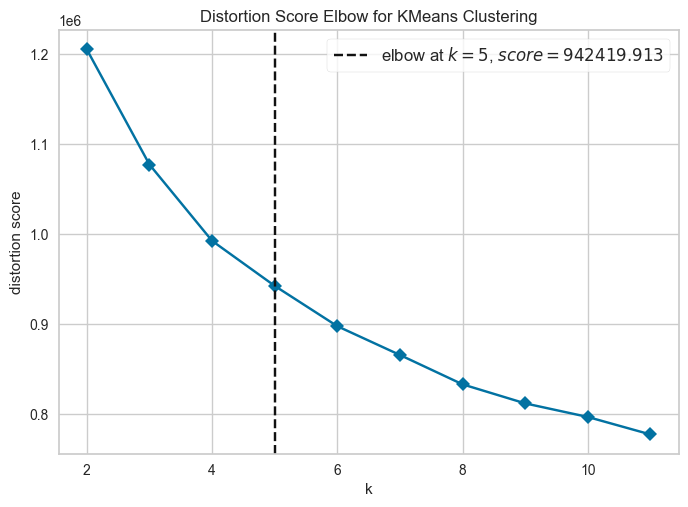

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Convert dataset to pandas and take 20% sample
cleaned_df_pd = cleaned_df.to_pandas()

sample_df = cleaned_df_pd.sample(frac=0.2, random_state=251467)

# Initializing K-means cluster algorithm
KClusterer = KMeans(n_clusters=3,verbose=0, random_state=251467466) 

# Initialize the object
visualizer = KElbowVisualizer(KClusterer, 
                              k=(2,12),   
                              locate_elbow=True, 
                              timings=False 
                             )

# Fit the data to the visualizer and render the figure
visualizer.fit(sample_df)        
visualizer.show()        




The silhouette score for K-Means Cluster with n_clusters = 3 is 0.153


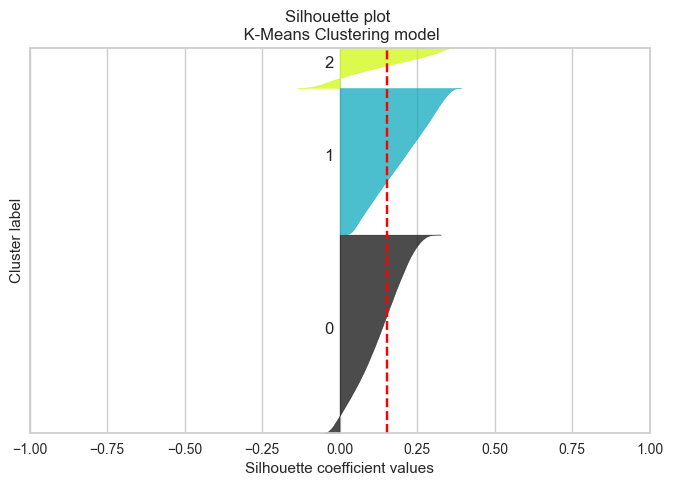


The silhouette score for K-Means Cluster with n_clusters = 4 is 0.145


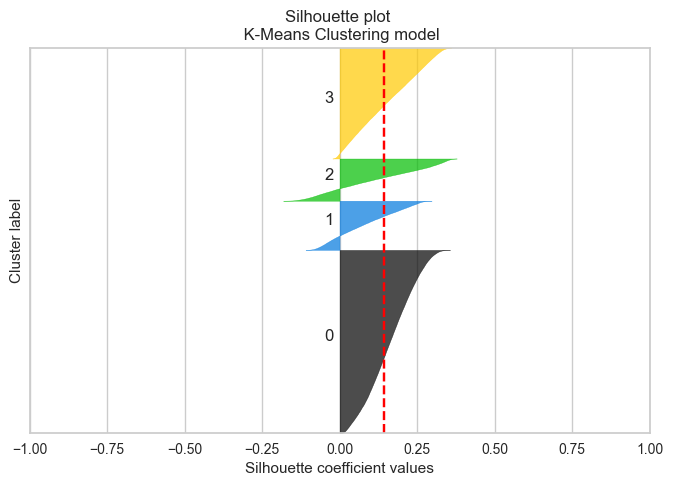


The silhouette score for K-Means Cluster with n_clusters = 5 is 0.113


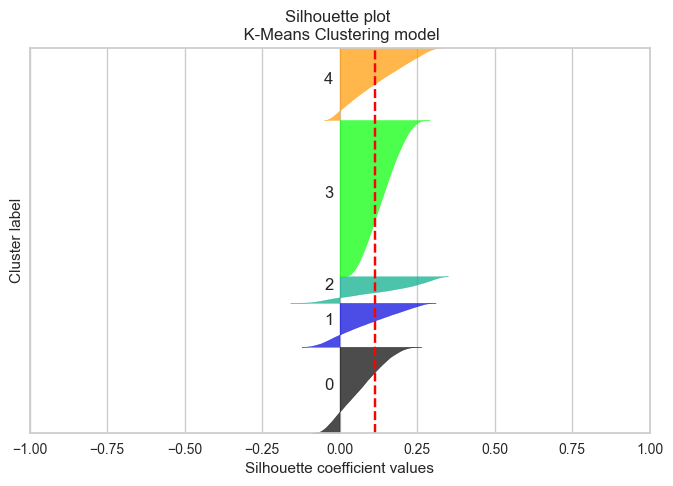


The silhouette score for K-Means Cluster with n_clusters = 6 is 0.105


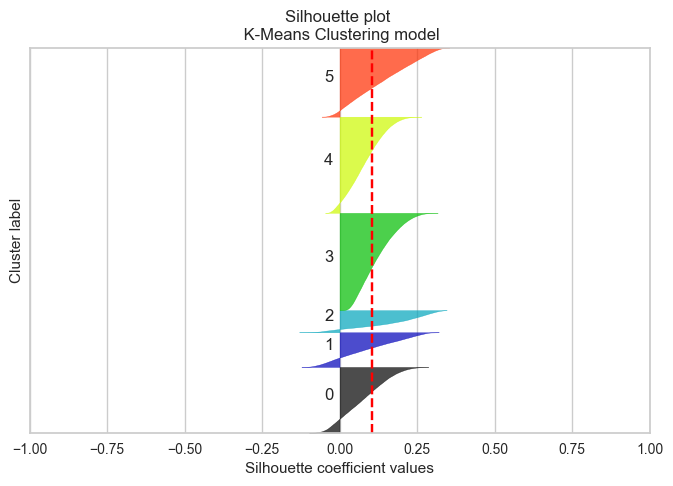

In [ ]:
# Test out between 4 - 6 clusters based on the graph from Elbow
range_n_clusters = range(3, 7)

for n_clusters in range_n_clusters:
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.set_xlim([-1, 1])
    ax1.set_ylim([0, len(sample_df) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, verbose=0, random_state=251467466)
    kmeans_cluster_labels = clusterer.fit_predict(sample_df)

    silhouette_avg = silhouette_score(sample_df, kmeans_cluster_labels)
    sample_silhouette_values = silhouette_samples(sample_df, kmeans_cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[kmeans_cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    print(f"\nThe silhouette score for K-Means Cluster with n_clusters = {n_clusters} is {silhouette_avg:.3f}")
    ax1.set_title("Silhouette plot \n K-Means Clustering model")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])

    plt.show()


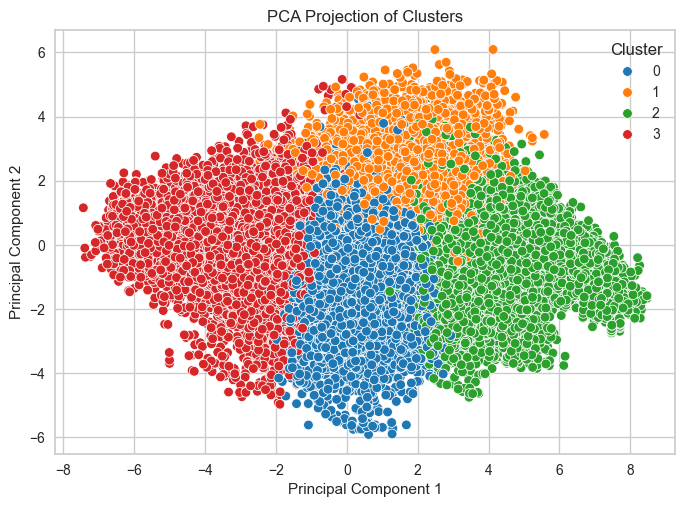

In [ ]:
#  Fit KMeans to our sample data
optimal_KCluster = KMeans(n_clusters=4, verbose=0, random_state=251467466)
sample_df['cluster_label'] = optimal_KCluster.fit_predict(sample_df)

#  Define and fit PCA to our data
nPCA = PCA(n_components=3)
Z1 = nPCA.fit_transform(sample_df.drop(columns='cluster_label'))

# Create Plot 
sns.scatterplot(x=Z1[:, 0], y=Z1[:, 1], hue=sample_df['cluster_label'], palette='tab10')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Clusters")
plt.legend(title='Cluster')
plt.show()


In [ ]:
# Get all features name
feature_names = sample_df.drop(columns='cluster_label').columns

for i, component in enumerate(nPCA.components_):
    top_indices = np.argsort(np.abs(component))[::-1][:3]  # top 3 features
    top_features = feature_names[top_indices]
    print(f"Top 3 features for Principal Component {i+1}: {list(top_features)}")


# Calculate the variance of the first 3 components.
explained_variance = nPCA.explained_variance_ratio_
print("Explained variance for each component:", explained_variance)
print("Total variance explained by first 3 components: {:.2f}%".format(np.sum(explained_variance) * 100))


Top 3 features for Principal Component 1: ['ECYCHAHHCH', 'ECYCHACFCH', 'ECYPTAAVG']
Top 3 features for Principal Component 2: ['ECYPFAAVG', 'ECYHFAAVG', 'ECYMTNAVG']
Top 3 features for Principal Component 3: ['ECYMTNAVG', 'ECYACTPR', 'ECYCHAHHCH']
Explained variance for each component: [0.36230721 0.11438017 0.09927974]
Total variance explained by first 3 components: 57.60%


In [ ]:
# Calculate average value of each component for each cluster

# Create a new DataFrame with PCA results and cluster labels
pca_df = pd.DataFrame(Z1, columns=['PC1', 'PC2', 'PC3'])
pca_df['cluster'] = sample_df['cluster_label']
print(sample_df['cluster_label'].value_counts())

cluster_pca_summary = pca_df.groupby('cluster')[['PC1', 'PC2', 'PC3']].mean().round(2)
cluster_pca_summary 

cluster_label
0    50072
3    30329
1    13458
2    11562
Name: count, dtype: int64


,PC1,PC2,PC3
cluster,,,
0.0,0.02,0.00,0.01
1.0,-0.07,-0.07,-0.10
2.0,0.01,-0.01,-0.03
3.0,0.01,0.01,-0.02


UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.3, n_epochs=1000, n_neighbors=50, verbose=True)
Sun Apr 13 04:01:17 2025 Construct fuzzy simplicial set
Sun Apr 13 04:01:17 2025 Finding Nearest Neighbors
Sun Apr 13 04:01:17 2025 Building RP forest with 21 trees
Sun Apr 13 04:01:17 2025 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	 4  /  17
	Stopping threshold met -- exiting after 4 iterations
Sun Apr 13 04:01:33 2025 Finished Nearest Neighbor Search
Sun Apr 13 04:01:34 2025 Construct embedding


Epochs completed:   1%|            7/1000 [00:00]

	completed  0  /  1000 epochs


Epochs completed:  10%| █          103/1000 [00:03]

	completed  100  /  1000 epochs


...

	completed  800  /  1000 epochs


Epochs completed:  90%| █████████  904/1000 [00:32]

	completed  900  /  1000 epochs


Epochs completed: 100%| ██████████ 1000/1000 [00:36]


Sun Apr 13 04:02:20 2025 Finished embedding


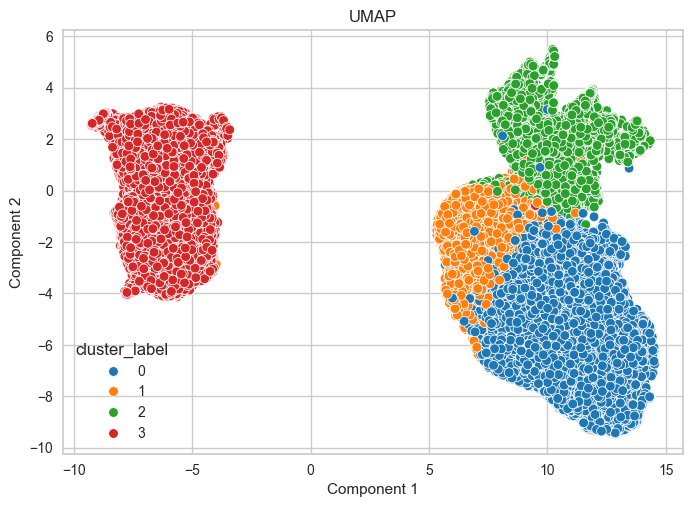

In [ ]:
# UMAP

import umap


# Define UMAP. Need to tune n_neighbors and min_dist for the ideal result
reducer = umap.UMAP(n_neighbors=50,             
                    n_components=2,            
                    metric='cosine',             
                    n_epochs=1000,              
                    min_dist=0.3,               
                    spread=1.0,                  
                    low_memory=False,                
                    verbose=True                 
                   )

# Fit the model
UMAP_embedding = reducer.fit_transform(sample_df)

# Create plot
sns.scatterplot(x=UMAP_embedding[:, 0], y=UMAP_embedding[:, 1], hue=sample_df['cluster_label'], palette='tab10')
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("UMAP")
plt.show()

# Part 2: Regression

In [ ]:
# Basic packages
import numpy as np
from functools import reduce
from io import BytesIO  # just for plotting

# Data handling
import pandas as pd
import polars as pl  # will use polars but xgboost is not robust for using polars

# Scikit-learn
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz  # have tree for regression or classifer depending on if target is continuous or discrete
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, BaggingRegressor, RandomForestRegressor
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, LabelEncoder  # one hot encoder for categorical variables but oh xgboost doesn't ALLOW categorical variables so need to transform first to dummy variables
from sklearn.compose import ColumnTransformer  # to do this
from sklearn.pipeline import Pipeline  # as we did before to do it automatically
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, ElasticNetCV
import xgboost as xgb

# SHAP for explainability
import shap



# Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from IPython.display import Image
import pydotplus  # specific plotting to plot trees
from tqdm import tqdm
import pyarrow
%matplotlib inline

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Import data

demo_data2 = pl.read_csv('/Users/anakarenvarelalopez/Library/CloudStorage/OneDrive-TheUniversityofWesternOntario/Machine Learning/Final project/DemoStats.csv')

housespend_data2 = pl.read_csv('/Users/anakarenvarelalopez/Library/CloudStorage/OneDrive-TheUniversityofWesternOntario/Machine Learning/Final project/HouseholdSpend.csv')

In [ ]:
# Check how many variables in each dataset
print(demo_data2.shape) # 736 variables
print(housespend_data2.shape) # 246 variables

(868970, 736)
(868970, 246)


In [ ]:
#Save columns available to identify in the metadata file
pd.DataFrame({'Columnm_name':demo_data2.columns}).to_csv('/Users/anakarenvarelalopez/Library/CloudStorage/OneDrive-TheUniversityofWesternOntario/Machine Learning/Final project/variables_demo_data2.csv')
pd.DataFrame({'Columnm_name':housespend_data2.columns}).to_csv('/Users/anakarenvarelalopez/Library/CloudStorage/OneDrive-TheUniversityofWesternOntario/Machine Learning/Final project/variables_housespend_data2.csv')

# Data preprocessing

## Demo Data Cleaning

In [ ]:
# Full set of DemoStats Data cleaning

# Drop useless columns such as "GEO", "ECYASQKM" (only zeros), "ECYALSQKM"
# Since the legal ageto work is 18, let's just keep info with this age or over
demo_data2 = demo_data2.drop(["GEO", "ECYASQKM", "ECYALSQKM", "ECYBAS12P", "ECYBAS15P", "ECYBAS19P",
                            "ECYBAS12HP","ECYBAS15HP","ECYBAS19HP"])

# Check the rows that has 0 Total population and we will remove them
demo_data2 = demo_data2.filter(pl.col("ECYBASPOP") != 0) 

# Check the rows that has 0 Total household and we will remove them
demo_data2 = demo_data2.filter(pl.col("ECYBASHHD") != 0)

# We also remove rows that have 0 Total Household Population 18 Years Or Over and Total Population 18 Years Or Over as this is not normal for a household
demo_data2= demo_data2.filter((pl.col("ECYBAS18P") != 0) & (pl.col("ECYBAS18HP") != 0))

# ECYPTAMED, ECYHTAMED, ECYMTNMED have null mean and standard deviation. We need to change the type of variable from string to numeric

str_to_num_variable = ["ECYPTAMED", "ECYHTAMED", "ECYMTNMED"]

demo_data2 = demo_data2.with_columns(pl.col(c).cast(pl.Float64).alias(c) for c in str_to_num_variable)

# ECYPMAMED, ECYPFAMED, ECYHMAMED, ECYHFAMED have null mean and standard deviation with "NA" value, we decided to calculate the median of the column then replace all "NA" with median

na_to_null_variable = ["ECYPMAMED", "ECYPFAMED", "ECYHMAMED", "ECYHFAMED"]  

# Convert "NA" to null and cast to Float64
demo_data2 = demo_data2.with_columns([
    pl.col(c).replace("NA", None).cast(pl.Float64).alias(c)
    for c in na_to_null_variable
])


# Descriptive Statistics 
demo_data2.describe()

statistic,CODE,ECYBASPOP,ECYBASHHD,ECYBASHPOP,ECYBAS18P,ECYBAS18HP,ECYBASTNGH,ECYBASADUH,ECYBASCF,ECYBASCFH,ECYBASKID,ECYBASLF,ECYPTAPOP,ECYPTA_0_4,ECYPTA_5_9,ECYPTA1014,ECYPTA1519,ECYPTA2024,ECYPTA2529,ECYPTA3034,ECYPTA3539,ECYPTA4044,ECYPTA4549,ECYPTA5054,ECYPTA5559,ECYPTA6064,ECYPTA6569,ECYPTA7074,ECYPTA7579,ECYPTA8084,ECYPTA85P,ECYPTAAVG,ECYPTAMED,ECYPMAPOP,ECYPMA_0_4,ECYPMA_5_9,…,ECYRIMINDI,ECYRIMNEPA,ECYRIMPAKI,ECYRIMSRI,ECYRIMSASO,ECYRIMOCE,ECYRIMAUSS,ECYRIMOCEO,ECYPIMHPOP,ECYPIMNI,ECYPIMIM,ECYPIMP01,ECYPIM0110,ECYPIM1115,ECYPIM1621,ECYPIM22CY,ECYPIMNPER,ECYAIMHPOP,ECYAIMNI,ECYAIMIM,ECYAIM_0_5,ECYAIM_514,ECYAIM1524,ECYAIM2544,ECYAIM45P,ECYAIMNPER,ECYGENHPOP,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCAHPOP,ECYTCACIT,ECYTCA_U18,ECYTCA_18P,ECYNCANCIT,ECYNCA_U18,ECYNCA_18P
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""776241""",776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,…,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,51.866222,20.634548,51.362697,41.952291,41.715506,3.439762,27.425884,14.285317,13.490988,14.262811,27.576361,51.866222,2.440537,2.674836,2.79577,2.982663,3.58555,3.692814,3.803167,3.637744,3.481198,3.191707,3.099513,3.189347,3.464588,3.122399,2.528886,1.948279,1.187799,1.039426,41.836432,42.429692,25.868748,1.25124,1.371392,…,0.534118,0.006372,0.043395,0.0098,0.000313,0.008141,0.005716,0.002425,51.362697,35.506094,13.162009,5.285503,2.651097,1.557887,1.836647,1.830875,2.694594,51.362697,35.506094,13.162009,1.193516,2.279847,2.496689,5.932432,1.259525,2.694594,51.362697,15.860689,8.338151,27.163856,51.362697,45.370139,8.68862,36.681519,5.992558,0.958571,5.033987
"""std""",null,184.066133,73.09698,181.015215,146.586827,144.503546,13.143899,92.301511,52.830782,50.412151,51.656878,94.108381,184.066133,10.038435,10.96825,11.288782,10.825752,11.407458,11.450941,12.306282,11.963397,11.682615,11.040961,11.106911,12.285005,14.438859,13.424042,10.977857,8.537598,5.192997,4.672792,7.569389,10.701491,95.384521,5.190325,5.624187,…,2.656351,0.131105,0.385263,0.151262,0.025806,0.125436,0.099892,0.061348,181.015215,157.986476,34.509474,15.014993,7.663929,4.845946,6.121115,6.066776,11.052846,181.015215,157.986476,34.509474,3.576906,6.424502,6.882798,15.651513,4.144793,11.052846,181.015215,42.201133,25.87303,139.187019,181.015215,172.743152,36.691379,137.500675,18.830793,3.382998,15.806954
"""min""","""A0A1A0""",1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.5,12.2,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",null,11.0,4.0,11.0,9.0,9.0,1.0,6.0,3.0,3.0,2.0,6.0,11.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,37.3,35.3,7.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,8.0,1

Applying the previous cleaning, we dropped 12%

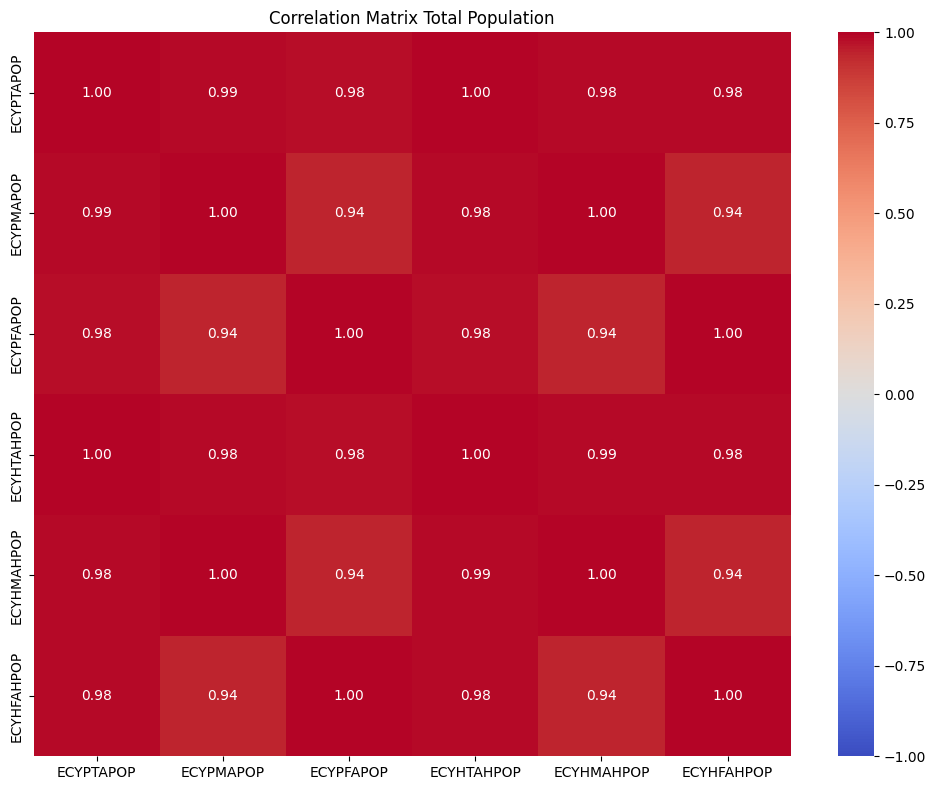

In [ ]:
# Corralation matrix of total population
corr_matrix = pl.DataFrame(demo_data2[[ 'ECYPTAPOP','ECYPMAPOP', 'ECYPFAPOP', 'ECYHTAHPOP','ECYHMAHPOP', 'ECYHFAHPOP']]).to_pandas().corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix Total Population')
plt.tight_layout()
plt.show()

As we expected, Total Population and Total Household Population are correlated. Moreover, the totals are correlated with female and male segments. We'll drop variables related to total population, since we want to model households; as well as totals.

To recude correlation among variables, we will also group some variables:

* Children: Typically defined as 0-14 years old.
* Youth: Often considered 15-29 years old.
* Adults: Generally defined as 30-64 years old.
* Seniors: Typically considered 65 years and older. 

In [ ]:
# Drop totals. Just keep:
# ECYPTAPOP	Total Population
# ECYPTAAVG	Average Age Of Total Population
# ECYPTAMED	Median Age Of Total Population

demo_data2 = demo_data2.drop(['ECYPTA_0_4','ECYPTA_5_9','ECYPTA1014','ECYPTA1519','ECYPTA2024',
'ECYPTA2529','ECYPTA3034','ECYPTA3539','ECYPTA4044','ECYPTA4549','ECYPTA5054','ECYPTA5559',
'ECYPTA6064','ECYPTA6569','ECYPTA7074','ECYPTA7579','ECYPTA8084','ECYPTA85P', 'ECYPMAPOP',
'ECYPMA_0_4','ECYPMA_5_9','ECYPMA1014','ECYPMA1519','ECYPMA2024','ECYPMA2529','ECYPMA3034',
'ECYPMA3539','ECYPMA4044','ECYPMA4549','ECYPMA5054','ECYPMA5559','ECYPMA6064','ECYPMA6569',
'ECYPMA7074','ECYPMA7579','ECYPMA8084','ECYPMA85P','ECYPMAAVG','ECYPMAMED','ECYPFAPOP',
'ECYPFA_0_4','ECYPFA_5_9','ECYPFA1014','ECYPFA1519','ECYPFA2024','ECYPFA2529','ECYPFA3034',
'ECYPFA3539','ECYPFA4044','ECYPFA4549','ECYPFA5054','ECYPFA5559','ECYPFA6064','ECYPFA6569',
'ECYPFA7074','ECYPFA7579','ECYPFA8084','ECYPFA85P','ECYPFAAVG','ECYPFAMED', 'ECYHTAHPOP',
'ECYHTA_0_4','ECYHTA_5_9','ECYHTA1014','ECYHTA1519','ECYHTA2024','ECYHTA2529','ECYHTA3034',
'ECYHTA3539','ECYHTA4044','ECYHTA4549','ECYHTA5054','ECYHTA5559','ECYHTA6064','ECYHTA6569',
'ECYHTA7074','ECYHTA7579','ECYHTA8084','ECYHTA85P','ECYHTAAVG','ECYHTAMED']) 

In [ ]:
# Group Household Population
demo_data2 = demo_data2.with_columns(
    (pl.col('ECYHMA_0_4') + pl.col('ECYHMA_5_9') + pl.col('ECYHMA1014')).alias("ECYHMA0_14"),
    (pl.col('ECYHMA1519') + pl.col('ECYHMA2024') + pl.col('ECYHMA2529')).alias("ECYHMA1529"),
    (pl.col('ECYHMA3034') + pl.col('ECYHMA3539') + pl.col('ECYHMA4044') + pl.col('ECYHMA4549') + 
    pl.col('ECYHMA5054') + pl.col('ECYHMA5559') + pl.col('ECYHMA6064')).alias("ECYHMA3064"),
    (pl.col('ECYHMA6569') + pl.col('ECYHMA7074') + pl.col('ECYHMA7579') + pl.col('ECYHMA8084') + pl.col('ECYHMA85P')).alias("ECYHMA6585P")
)

demo_data2 = demo_data2.with_columns(
    (pl.col('ECYHFA_0_4') + pl.col('ECYHFA_5_9') + pl.col('ECYHFA1014')).alias("ECYHFA0_14"),
    (pl.col('ECYHFA1519') + pl.col('ECYHFA2024') + pl.col('ECYHFA2529')).alias("ECYHFA1529"),
    (pl.col('ECYHFA3034') + pl.col('ECYHFA3539') + pl.col('ECYHFA4044') + pl.col('ECYHFA4549') + 
    pl.col('ECYHFA5054') + pl.col('ECYHFA5559') + pl.col('ECYHFA6064')).alias("ECYHFA3064"),
    (pl.col('ECYHFA6569') + pl.col('ECYHFA7074') + pl.col('ECYHFA7579') + pl.col('ECYHFA8084') + pl.col('ECYHFA85P')).alias("ECYHFA6585P")
)

In [ ]:
# Drop household variables after grouping
demo_data2 = demo_data2.drop(['ECYHMAHPOP','ECYHMA_0_4','ECYHMA_5_9','ECYHMA1014','ECYHMA1519',
'ECYHMA2024','ECYHMA2529','ECYHMA3034','ECYHMA3539','ECYHMA4044','ECYHMA4549','ECYHMA5054',
'ECYHMA5559','ECYHMA6064','ECYHMA6569','ECYHMA7074','ECYHMA7579','ECYHMA8084','ECYHMA85P',
'ECYHFAHPOP','ECYHFA_0_4','ECYHFA_5_9','ECYHFA1014','ECYHFA1519','ECYHFA2024','ECYHFA2529',
'ECYHFA3034','ECYHFA3539','ECYHFA4044','ECYHFA4549','ECYHFA5054','ECYHFA5559','ECYHFA6064',
'ECYHFA6569','ECYHFA7074','ECYHFA7579','ECYHFA8084','ECYHFA85P'])

In [ ]:
# Group Households For Maintainer Age
demo_data2 = demo_data2.with_columns(
    (pl.col('ECYMTN1524') + pl.col('ECYMTN2534')).alias("ECYMTN1534"),
    (pl.col('ECYMTN3544') + pl.col('ECYMTN4554') + pl.col('ECYMTN5564')).alias("ECYMTN3564"),
    (pl.col('ECYMTN6574') + pl.col('ECYMTN7584') + pl.col('ECYMTN85P')).alias("ECYMTN6585P"),
 )

# Drop household variables after grouping
demo_data2 = demo_data2.drop(['ECYMTN1524','ECYMTN2534','ECYMTN3544','ECYMTN4554',
'ECYMTN5564','ECYMTN6574','ECYMTN7584','ECYMTN85P',])

In [ ]:
# Drop totals (Hierarchy Level=0,1,2)
demo_data2 = demo_data2.drop(['ECYHTYHHD','ECYHTYFHT','ECYHTY1FH', 'ECYMARMCL', 'ECYCFSCF',
'ECYCFSC','ECYCFSCNC','ECYCFSCWC','ECYCFSM','ECYCFSMNC','ECYCFSMWC','ECYCFSCL','ECYCFSCLNC',
'ECYCFSCLWC','ECYCFSLP','ECYCFSFP','ECYCFSMP', 'ECYHFSCF','ECYHFSC','ECYHFSCNC','ECYHFSCWC',
'ECYHFSM', 'ECYHFSCL', 'ECYHFSLP', 'ECYCHAKIDS', 'ECYCHACFCH', 'ECYMOBHPOP', 'ECYTENHHD',
'ECYPOCHHD', 'ECYSTYHHD','ECYSTYHOUS', 'ECYSTYAPT', 'ECYSTYOTHR', 'ECYCDOHHD','ECYCDOCO', 'ECYHRIHHD',
'ECYHRI100P', 'ECYHNIHHD', 'ECYHNI100P', 'ECYPNIHP15','ECYEDAHPWK','ECYEDANCDD','ECYEDAHSCE',
'ECYEDAATCD','ECYEDACOLL','ECYEDAUDBB','ECYEDAUD','ECYEDAUDBD','ECYEDAUDBP','ECYACTHPL','ECYACTINLF',
'ECYCWHPL','ECYCWT','ECYOCCHPL','ECYOCCINLF','ECYOCCALL','ECYINDHPL','ECYINDINLF','ECYINDALL',
'ECYPOWHPL','ECYPOWEMP','ECYTRADRIV','ECYTRAPSGR','ECYTRAPUBL','ECYTRAWALK','ECYTRABIKE',
'ECYTRAOTHE','ECYRELHPOP','ECYRELANGL','ECYRELCATH','ECYRELUNIT','ECYRELOCHR','ECYVISHPOP',
'ECYVISVM','ECYAIDHPOP','ECYKNOHPOP','ECYMOTHPOP','ECYMOTSING','ECYMOTITAL','ECYMOTGERM',
'ECYMOTPANJ','ECYMOTCANT','ECYMOTSPAN','ECYMOTARAB','ECYMOTTAGA','ECYMOTPORT','ECYMOTPOLI',
'ECYMOTMAND','ECYMOTCHIN','ECYMOTURDU','ECYMOTVIET','ECYMOTUKRA','ECYMOTPERS','ECYMOTRUSS',
'ECYMOTDUTC','ECYMOTKORE','ECYMOTGREE','ECYMOTTAMI','ECYMOTGUJA','ECYMOTROMA','ECYMOTHIND',
'ECYMOTHUNG','ECYMOTCROA','ECYMOTCREO','ECYMOTSERB','ECYMOTBENG','ECYMOTJAPA','ECYMOTTURK',
'ECYMOTCZEC','ECYMOTSOMA','ECYMOTABOR','ECYMOTOTHR','ECYMOTMULT','ECYHOMHPOP','ECYHOMSING',
'ECYHOMITAL','ECYHOMGERM','ECYHOMPANJ','ECYHOMCANT','ECYHOMSPAN','ECYHOMARAB','ECYHOMTAGA',
'ECYHOMPORT','ECYHOMPOLI','ECYHOMMAND','ECYHOMCHIN','ECYHOMURDU','ECYHOMVIET','ECYHOMUKRA',
'ECYHOMPERS','ECYHOMRUSS','ECYHOMDUTC','ECYHOMKORE','ECYHOMGREE','ECYHOMTAMI','ECYHOMGUJA',
'ECYHOMROMA','ECYHOMHIND','ECYHOMHUNG','ECYHOMCROA','ECYHOMCREO','ECYHOMSERB','ECYHOMBENG',
'ECYHOMJAPA','ECYHOMTURK','ECYHOMCZEC','ECYHOMSOMA','ECYHOMABOR','ECYHOMOTHR','ECYHOMMULT',
'ECYTIMHPOP','ECYTIMIMGT','ECYTIMAM','ECYTIMNAM','ECYTIMELSA','ECYTIMMEXI','ECYTIMOCAM',
'ECYTIMCUBA','ECYTIMHAIT','ECYTIMJAMA','ECYTIMTRIN','ECYTIMOCB','ECYTIMBRAZ','ECYTIMCHIL',
'ECYTIMCOLO','ECYTIMGUYA','ECYTIMPERU','ECYTIMVENE','ECYTIMOSAM','ECYTIMWEU','ECYTIMFRAN',
'ECYTIMGERM','ECYTIMNETH','ECYTIMOWEU','ECYTIMEEU','ECYTIMCZEC','ECYTIMHUNG','ECYTIMMOLD',
'ECYTIMPOLA','ECYTIMROMA','ECYTIMRUSS','ECYTIMUKRA','ECYTIMOEEU','ECYTIMNEU','ECYTIMUK',
'ECYTIMIREL','ECYTIMONEU','ECYTIMSEU','ECYTIMGREE','ECYTIMITAL','ECYTIMPORT','ECYTIMBOSN',
'ECYTIMCROA','ECYTIMSERB','ECYTIMOSEU','ECYTIMWAF','ECYTIMCOTE','ECYTIMGHAN','ECYTIMNIGE',
'ECYTIMOWAF','ECYTIMEAF','ECYTIMERIT','ECYTIMETHI','ECYTIMKENY','ECYTIMSOMA','ECYTIMTANZ',
'ECYTIMOEAF','ECYTIMCAF','ECYTIMCAME','ECYTIMCONG','ECYTIMCAFO','ECYTIMNAF','ECYTIMALGE',
'ECYTIMEGYP','ECYTIMMORO','ECYTIMTUNI','ECYTIMONAF','ECYTIMSAF','ECYTIMSAFR','ECYTIMOSAF',
'ECYTIMWCA','ECYTIMAFGH','ECYTIMIRAN','ECYTIMIRAQ','ECYTIMISRA','ECYTIMLEBA','ECYTIMSAUD',
'ECYTIMSYRI','ECYTIMTURK','ECYTIMUAE','ECYTIMOWCA','ECYTIMEA','ECYTIMCHIN','ECYTIMHONG',
'ECYTIMJAPA','ECYTIMSKOR','ECYTIMTAIW','ECYTIMOEA','ECYTIMSEA','ECYTIMCAMB','ECYTIMMALA',
'ECYTIMPHIL','ECYTIMVIET','ECYTIMOSEA','ECYTIMSA','ECYTIMBANG','ECYTIMINDI','ECYTIMNEPA',
'ECYTIMPAKI','ECYTIMSRI','ECYTIMOSA','ECYTIMAUSS','ECYTIMFIJI','ECYTIMOOCE','ECYRIMRIM',
'ECYRIMAM','ECYRIMNAM','ECYRIMCB','ECYRIMCUBA','ECYRIMHAIT','ECYRIMJAMA','ECYRIMCBO',
'ECYRIMBRAZ','ECYRIMCOLO','ECYRIMVENE','ECYRIMSAO','ECYRIMWEU','ECYRIMFRAN','ECYRIMGERM',
'ECYRIMWEO','ECYRIMEEU','ECYRIMMOLD','ECYRIMPOLA','ECYRIMROMA','ECYRIMRUSS','ECYRIMUKRA',
'ECYRIMEEO','ECYRIMNEU','ECYRIMUK','ECYRIMNEO','ECYRIMSEU','ECYRIMWAF','ECYRIMCOTE',
'ECYRIMNIGE','ECYRIMWAFO','ECYRIMEAF','ECYRIMERIT','ECYRIMETHI','ECYRIMKENY','ECYRIMSOMA',
'ECYRIMEAFO','ECYRIMCAF','ECYRIMNAF','ECYRIMALGE','ECYRIMEGYP','ECYRIMMORO','ECYRIMTUNI',
'ECYRIMNAFO','ECYRIMSAF','ECYRIMWCM','ECYRIMAFGH','ECYRIMIRAN','ECYRIMIRAQ','ECYRIMISRA',
'ECYRIMLEBA','ECYRIMSAUD','ECYRIMSYRI','ECYRIMTURK','ECYRIMUAE','ECYRIMWCMO','ECYRIMEA',
'ECYRIMCHIN','ECYRIMHONG','ECYRIMJAPA','ECYRIMSKOR','ECYRIMEAO','ECYRIMSEA','ECYRIMPHIL',
'ECYRIMVIET','ECYRIMSEAO','ECYRIMSAS','ECYRIMBANG','ECYRIMINDI','ECYRIMNEPA','ECYRIMPAKI',
'ECYRIMSRI','ECYRIMSASO','ECYRIMAUSS','ECYRIMOCEO','ECYPIMHPOP','ECYPIMP01','ECYPIM0110',
'ECYPIM1115','ECYPIM1621','ECYPIM22CY','ECYAIMHPOP','ECYAIM_0_5','ECYAIM_514','ECYAIM1524',
'ECYAIM2544','ECYAIM45P','ECYGENHPOP','ECYTCAHPOP','ECYTCACIT','ECYNCANCIT', 'ECYHSZHHD',
'ECYCDONC',
]) 

In [ ]:
demo_data2.shape

(776241, 264)

We reduced 63.9%% the Demo data set. We passed from 736 to 266 variables.

## House Spend Data Cleaning

In [ ]:
housespend_data2.shape

(868970, 246)

In [ ]:
#Unique rows
housespend_data2.group_by(pl.col("CODE")).count().sort("count",descending=True).shape

/var/folders/qh/8xvsb7ss1t9043zm17zm38x40000gn/T/ipykernel_35069/2480598030.py:2: DeprecationWarning: `GroupBy.count` is deprecated. It has been renamed to `len`.
  housespend_data2.group_by(pl.col("CODE")).count().sort("count",descending=True).shape


(868970, 2)

In [ ]:
housespend_data2.describe()

statistic,CODE,GEO,HSBASHHD,HSHNIAGG,HSAGDISPIN,HSAGDISCIN,HSTT001,HSTE001,HSTX001,HSTC001,HSSH001S,HSFD001S,HSHO001S,HSHC001S,HSHF001S,HSTR001S,HSRE001S,HSPC001S,HSCL001S,HSED002S,HSRO001S,HSTA001S,HSGC001S,HSME001S,HSEP001S,HSMG001S,HSTE001ZBS,HSWH002S,HSWH028S,HSWH040S,HSWH041S,HSWH042S,HSSH001,HSSH002,HSSH003,HSSH004,…,HSTR002,HSTR003,HSTR004,HSTR005,HSTR006,HSTR007,HSTR008,HSTR009,HSTR058,HSTR010,HSTR011,HSTR012,HSTR014M,HSTR015,HSTR020,HSTR030,HSTR031,HSTR032,HSTR033,HSTR034,HSTR035,HSTR036,HSTR037,HSTR038,HSTR039,HSTR040,HSTR041,HSTR050,HSTR051,HSTR052,HSTR053,HSTR054,HSTR055,HSTR056,HSTR056A,HSTR056B,HSTR057
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""868970""","""868970""",868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,…,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0,868970.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,18.432629,2.2534e6,1.7170e6,1.2342e6,2.4008e6,2.1917e6,421335.834661,1.6065e6,388812.651163,278016.994627,111401.557243,109343.827301,76103.411113,271135.371662,87929.804561,45315.650319,70798.452452,34398.504565,3570.867859,70468.350013,25849.158365,33310.372386,115213.19111,48732.91062,209040.481816,67544.21004,4806.924846,112565.256385,15089.24985,9034.840695,388812.651163,303764.492909,89251.190609,88053.450315,…,236398.761036,118477.006209,114562.677761,14888.288571,8607.895903,91066.493288,188.957063,83.539013,105.41805,3725.371385,3469.552047,2092.59778,1376.954267,255.819338,1504.664209,116417.090618,3287.664753,10103.061471,12676.188385,18214.142317,100.530695,63415.559732,2639.560863,4612.181943,1368.200459,379.01064,989.189819,34736.610626,5995.306708,2258.469958,915.416319,23038.220756,71.1409,1322.434304,831.592595,490.84171,1135.621681
"""std""",null,null,69.379951,8.2787e6,6.3276e6,4.6340e6,9.1329e6,8.0562e6,1.5969e6,5.9255e6,1.3661e6,1.0471e6,420881.63654,429642.774397,290959.592849,1.0751e6,327376.60947,163377.943862,249311.269506,114999.916794,14386.745375,264786.580294,94955.831503,127397.296924,431645.982804,206454.726959,1.2713e6,341440.420828,40531.631801,898861.389623,51492.602769,35858.838458,1.3661e6,1.0270e6,292325.224526,287942.333453,…,990960.632583,507452.95803,494184.487741,58848.760548,45895.371562,398856.15598,794.022208,358.55285,497.256289,14112.764792,13213.369738,8173.498909,5705.767025,1422.161917,5673.303299,486744.921092,14400.182837,39378.141535,60281.31644,71889.568827,615.785308,284702.777168,13567.714202,14917.235034,5725.037991,2091.296014,3882.026395,101629.434794,19414.670337,7613.821326,5037.673958,71509.135272,257.018871,6638.799848,5076.885882,2097.649493,4203.801021
"""min""","""A0A0A0""","""FSALDU""",0.0,0.0,0.0,0.0,-24249.492537,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.4599e7,0.0,0.0,-1.6806e7,-26676.98553,-204380.698719,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [ ]:
# Count weird negative cases
housespend_data2.filter((pl.col("HSTT001") < 0) | (pl.col("HSTE001ZBS") < 0)).shape
# It represents 18.82% of the total data set, lets keep all obs

(163557, 246)

In [ ]:
# Since we do not have any data of household refunds, subsidies, financial adjustments, we believe that it is 
# invalid to have both "Total Expenditure" and "Total Non-Current Consumption" as negative values, thus we remove them

#housespend_data2 = housespend_data2.filter((pl.col("HSTT001") >= 0) & (pl.col("HSTE001ZBS") >= 0))

#housespend_data2.describe()

Is it possible that these variables take negative values?
* 'HSWH040S' Net purchase price of owned residences
* 'HSWH041S' Net purchase price of owned secondary residences
* 'HSWH042S' Net purchase price of other owned properties

In [ ]:
# Remove useless columns
housespend_data2 = housespend_data2.drop(['GEO', 'HSTT001','HSTE001','HSTC001','HSTE001ZBS','HSWH042S','HSSH001','HSSH002',
'HSSH004','HSSH053','HSSH054','HSSH005','HSSH006','HSSH007','HSSH011','HSSH014','HSSH013','HSSH015',
'HSSH016','HSSH017','HSSH018','HSSH019','HSSH021','HSSH020','HSSH022','HSSH012','HSRM002A','HSRM002B',
'HSRM003A','HSRM003B','HSRM004','HSRM005','HSRM006','HSRM007','HSRM008M','HSRM009A','HSRM009B',
'HSRM010','HSRM011','HSRM012','HSRM013','HSRM015M','HSRM016','HSSH012B','HSOI020','HSOI020Z',
'HSSH031','HSSH031A','HSSH031B','HSSH032','HSSH032A','HSSH032B','HSSH033','HSSH033A','HSSH033B',
'HSSH034','HSSH035','HSSH035A','HSSH035B','HSSH036','HSSH036A','HSSH036B','HSSH037','HSSH037A',
'HSSH037B','HSSH040','HSSH042','HSSH043','HSSH044','HSSH045','HSSH046','HSSH046C','HSSH046M',
'HSSH047A','HSSH047C','HSSH047M','HSSH051','HSSH052','HSFD001','HSFD991','HSFD992','HSFD993',
'HSFD994','HSFD995','HSHO001','HSHO004','HSHO005','HSHO006','HSHO011','HSHO012','HSHO013',
'HSHO015','HSHO016','HSHO017','HSHO019','HSHO020','HSHO021','HSCC001','HSCC003','HSCC013','HSCC011',
'HSCC012','HSCS001','HSCS004','HSCS005','HSCS011','HSCS012','HSCS013','HSHC001','HSHC002','HSHC004A',
'HSHC004B','HSHC006','HSHC006A','HSHC006B','HSHC007','HSHC008','HSHC009','HSHC012','HSHC014','HSHC027',
'HSHC022','HSHF001','HSHF003','HSHF004','HSHF005','HSHF005A','HSHF005B','HSHF006','HSHF008','HSHE002',
'HSHE003','HSHE004','HSHE005','HSHE006','HSHE007','HSHE009','HSHE008','HSHE010','HSHE011','HSHE011A',
'HSHE011B','HSHE031','HSHE012','HSHE012M','HSHE032','HSHE013','HSHE015','HSHE021','HSHE023','HSTR001',
'HSTR002','HSTR004','HSTR005','HSTR006','HSTR007','HSTR008','HSTR009','HSTR058','HSTR010','HSTR011',
'HSTR012','HSTR014M','HSTR015','HSTR031','HSTR032','HSTR033','HSTR034','HSTR035','HSTR036','HSTR037',
'HSTR038','HSTR039','HSTR040','HSTR041','HSTR050','HSTR056A','HSTR056B',])

We reduced 72.3% the Household spend data set. We passed from 246 to 68 variables.

In [ ]:
print(f'Final Demo data set: {demo_data2.shape}, Household Spend data set: {housespend_data2.shape}')

Final Demo data set: (776241, 264), Household Spend data set: (868970, 68)


## General data cleaning

In [ ]:
# Merge both datasets together

# Perform an inner join to find the intersection based on postal_code
df_intersection = housespend_data2.join(demo_data2, on="CODE", how="inner")

# Display result
df_intersection.describe()

statistic,CODE,HSBASHHD,HSHNIAGG,HSAGDISPIN,HSAGDISCIN,HSTX001,HSSH001S,HSFD001S,HSHO001S,HSHC001S,HSHF001S,HSTR001S,HSRE001S,HSPC001S,HSCL001S,HSED002S,HSRO001S,HSTA001S,HSGC001S,HSME001S,HSEP001S,HSMG001S,HSWH002S,HSWH028S,HSWH040S,HSWH041S,HSSH003,HSSH010,HSSH030,HSSH041,HSSH047,HSSH050,HSFD003,HSFD990,HSHO002,HSHO003,…,ECYTIMAF,ECYTIMA,ECYTIMOCE,ECYTIMNPER,ECYRIMHPOP,ECYRIMCAM,ECYRIMMEXI,ECYRIMCAO,ECYRIMSAM,ECYRIMEU,ECYRIMAF,ECYRIMA,ECYRIMOCE,ECYPIMNI,ECYPIMIM,ECYPIMNPER,ECYAIMNI,ECYAIMIM,ECYAIMNPER,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCA_U18,ECYTCA_18P,ECYNCA_U18,ECYNCA_18P,ECYHMA0_14,ECYHMA1529,ECYHMA3064,ECYHMA6585P,ECYHFA0_14,ECYHFA1529,ECYHFA3064,ECYHFA6585P,ECYMTN1534,ECYMTN3564,ECYMTN6585P
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""776241""",776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,…,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0,776241.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,20.634548,2.5226e6,1.9221e6,1.3816e6,471667.847761,435259.320402,311228.308738,124709.347994,122405.835283,85194.538125,303524.545266,98433.69803,50728.959869,79255.884152,38507.694218,3997.436711,78886.331422,28937.053578,37289.562089,128976.278123,54554.476045,75612.868336,5381.152671,126011.234732,16891.766655,99912.987873,205295.618399,34842.869946,52436.665236,7004.937482,35766.241466,200457.007131,110771.301608,9364.629321,17578.013224,…,1.434754,7.051688,0.093865,2.694594,51.362697,0.030618,0.022119,0.008499,0.07253,0.126668,0.330899,1.172533,0.008141,35.506094,13.162009,2.694594,35.506094,13.162009,2.694594,15.860689,8.338151,27.163856,8.68862,36.681519,0.958571,5.033987,4.040897,5.287563,11.854628,4.458654,3.850487,4.927561,11.89604,5.046867,3.708342,11.032156,5.89405
"""std""",null,73.09698,8.7203e6,6.6653e6,4.8822e6,1.6825e6,1.4384e6,1.1032e6,443444.381996,452819.36308,306587.82044,1.1331e6,344883.468854,172065.07407,262508.915823,121023.103006,15165.709581,278968.438629,100021.860742,134240.534427,454753.324394,217710.214728,360413.943924,42848.247403,950144.599078,54201.34169,307566.348024,721473.97151,145555.941906,194463.0624,53444.630973,139412.282919,727491.227638,380635.751521,34306.914857,80616.179627,…,5.227492,21.47382,0.566282,11.052846,181.015215,0.295526,0.25248,0.113756,0.448361,0.728762,1.482881,4.47997,0.125436,157.986476,34.509474,11.052846,157.986476,34.509474,11.052846,42.201133,25.87303,139.187019,36.691379,137.500675,3.382998,15.806954,16.440957,17.394916,42.28767,20.309085,15.767384,15.472271,40.72751,20.68867,13.255415,38.482873,25.358463
"""min""","""A0A1A0""",1.0,86.909787,85.045341,28.594164,0.107058,10.809524,25.392597,13.931705,7.351227,2.856428,6.992511,1.608309,2.493649,4.847665,0.165993,0.225927,1.162679,0.591767,1.351504,0.634796,1.458431,0.002444,0.206311,-1.6806e7,-26676.98553,0.031874,0.000772,0.831214,0.0928,0.00334,0.220536,21.731132,3.661465,0.080235,0.280917,…,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0

In [ ]:
#Validate unique rows
df_intersection.group_by(pl.col("CODE")).count().sort("count",descending=True).shape

/var/folders/qh/8xvsb7ss1t9043zm17zm38x40000gn/T/ipykernel_35069/2671937075.py:2: DeprecationWarning: `GroupBy.count` is deprecated. It has been renamed to `len`.
  df_intersection.group_by(pl.col("CODE")).count().sort("count",descending=True).shape


(776241, 2)

**Target**

We will create models for a household’s proportion of income spent on total personal insurance premiums and retirement/pension contributions.

Options of household income:
* HSHNIAGG	Household Income - Gross income
* HSAGDISPIN	Household Disposable Income - This is what’s left after taxes and mandatory payments. * (Disposable Income=Household Income−Taxes)
* HSAGDISCIN	Household Discretionary Income - This is what's left after covering all essential expenses (Discretionary Income=Disposable Income−Necessities)

Target = Total personal insurance premiums and retirement/pension contributions / Household Disposable Income 

In [ ]:
# Create target
df_intersection = df_intersection.with_columns(
    (pl.col('HSEP001S')/pl.col('HSAGDISPIN')).alias("TARGET"),
 )

In [ ]:
corr_matrix = pl.DataFrame(df_intersection.drop("CODE")).to_pandas().corr()

In [ ]:
# Highly correlated variables  (>.9)
# Convert to DataFrame for easier filtering
corr_df = corr_matrix.stack().reset_index()
corr_df.columns = ['var1', 'var2', 'correlation']

# Filter for correlations above 0.8 (absolute value)
high_correlations = corr_df[abs(corr_df['correlation']) > 0.9]

# Remove self-correlations (which are always 1.0)
high_correlations = high_correlations[high_correlations['var1'] != high_correlations['var2']]

# Remove duplicates (e.g., if we have both A→B and B→A)
high_correlations = high_correlations[high_correlations['var1'] < high_correlations['var2']]

# Sort by correlation strength (descending)
high_correlations = high_correlations.sort_values('correlation', ascending=False)

#Save table to get correlated vars
#pd.DataFrame(high_correlations).to_csv('/Users/anakarenvarelalopez/Library/CloudStorage/OneDrive-TheUniversityofWesternOntario/Machine Learning/Final project/high_correlations.csv')

In [ ]:
# Drop the CODE column because we no longer need it after we merge both datasets
df_intersection = df_intersection.drop("CODE")

# We also need to drop our target variables, including all incomes and the expenditure on pensions
df_intersection = df_intersection.drop(['HSEP001S', 'HSHNIAGG', 'HSAGDISPIN', 'HSAGDISCIN', 'HSHC023', 'HSHC024', 'HSHC025'])

In [ ]:
# Elasticnet is able to handle correlated variables, but let's help it dropping one of those highly correlated variables (>.9)
# that are correlated with more than 100 variables
df_intersection = df_intersection.drop(['ECYBASPOP','ECYBASHHD','ECYBASHPOP','ECYBAS18P','ECYBAS18HP','ECYBASADUH',
'ECYBASCF','ECYBASCFH','ECYBASKID','ECYBASLF','ECYCFSNFP','ECYHNIAGG',
'ECYEDUHP15','ECYEDUHSCE','ECYEDUCOLL','ECYACTEMP','ECYCWEMP','ECYAIDNABO','ECYAIMNI', 'HSWH041S'])

In [ ]:
df_intersection.shape

(776241, 304)

In [ ]:
# Get train and test splits
X_train, X_test, y_train, y_test = train_test_split(df_intersection.drop('TARGET'),
                                                    df_intersection.select('TARGET'),
                                                    test_size = 0.3,
                                                    random_state = 2025)

In [ ]:
X_train.describe(percentiles=[.8,.9, .95,.975,.99])

statistic,HSBASHHD,HSTX001,HSSH001S,HSFD001S,HSHO001S,HSHC001S,HSHF001S,HSTR001S,HSRE001S,HSPC001S,HSCL001S,HSED002S,HSRO001S,HSTA001S,HSGC001S,HSME001S,HSMG001S,HSWH002S,HSWH028S,HSWH040S,HSSH003,HSSH010,HSSH030,HSSH041,HSSH047,HSSH050,HSFD003,HSFD990,HSHO002,HSHO003,HSHO010,HSHO014,HSHO018,HSHO022,HSCC002,HSCC014,…,ECYTIMEU,ECYTIMAF,ECYTIMA,ECYTIMOCE,ECYTIMNPER,ECYRIMHPOP,ECYRIMCAM,ECYRIMMEXI,ECYRIMCAO,ECYRIMSAM,ECYRIMEU,ECYRIMAF,ECYRIMA,ECYRIMOCE,ECYPIMNI,ECYPIMIM,ECYPIMNPER,ECYAIMIM,ECYAIMNPER,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCA_U18,ECYTCA_18P,ECYNCA_U18,ECYNCA_18P,ECYHMA0_14,ECYHMA1529,ECYHMA3064,ECYHMA6585P,ECYHFA0_14,ECYHFA1529,ECYHFA3064,ECYHFA6585P,ECYMTN1534,ECYMTN3564,ECYMTN6585P
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,…,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0,543368.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",20.529266,468719.824883,433052.924942,309505.053195,123966.497207,121708.879449,84688.172187,301777.962076,97903.967829,50492.858814,78853.354684,38331.281697,3975.982212,78415.56258,28776.61187,37068.088873,54113.508441,75131.549577,5396.795914,124617.399144,99650.395656,204224.453087,34614.274734,52075.838919,6937.06957,35550.892976,199379.920697,110125.132498,9295.958436,17433.709016,4830.936352,8140.157463,13046.00198,2798.24384,7117.617198,1721.437244,…,2.727789,1.43186,7.052741,0.093279,2.686483,51.136578,0.03027,0.022004,0.008267,0.07206,0.125626,0.33059,1.172283,0.008009,35.311998,13.138096,2.686483,13.138096,2.686483,15.828578,8.306161,27.001839,8.656419,36.509285,0.954145,5.016729,4.026995,5.273664,11.810648,4.426472,3.833768,4.910392,11.843355,5.011285,3.69471,10.982658,5.851898
"""std""",72.410857,1.6577e6,1.4221e6,1.0909e6,437504.04869,445340.156765,301310.510695,1.1182e6,340835.607292,172105.738477,261110.192203,119972.882142,14986.396509,274461.774305,98236.649917,132720.090926,204970.720107,356576.757117,44001.582739,941604.556881,307645.34779,716465.149556,142852.865415,190544.284309,52163.573245,137709.876988,721269.497214,374632.618768,33577.758742,78932.38892,17910.4416,30418.725737,55300.486762,11171.587588,28123.952194,6933.905665,…,9.427897,5.256714,21.837928,0.558712,11.054654,180.132414,0.28579,0.243279,0.109414,0.446431,0.700047,1.488954,4.553397,0.119097,156.867472,34.877351,11.054654,34.877351,11.054654,42.553094,25.796264,138.212778,36.855198,136.33536,3.380938,15.869161,16.557056,17.486592,42.335456,19.868999,15.807462,15.471511,40.630063,20.169026,13.275499,38.438689,24.733691
"""min""",1.0,0.575162,107.294159,182.74468,51.376599,35.947021,14.75461,59.090571,14.805073,16.315284,30.498443,0.643346,1.517354,6.151733,1.919018,4.945351,2.237534,0.011479,0.206311,-1.6042e7,0.035175,0.003409,5.050015,0.704886,0.183764,0.581881,133.377719,16.126656,0.15347,0.878936,2.506295,3.865604,0.763761,0.71811,0.066789,0.020161,…,0.0,0.0,0.0,0.0,0.0,1.0,0.0,

In [ ]:
X_test.describe(percentiles=[.8,.9, .95,.975, .99])

statistic,HSBASHHD,HSTX001,HSSH001S,HSFD001S,HSHO001S,HSHC001S,HSHF001S,HSTR001S,HSRE001S,HSPC001S,HSCL001S,HSED002S,HSRO001S,HSTA001S,HSGC001S,HSME001S,HSMG001S,HSWH002S,HSWH028S,HSWH040S,HSSH003,HSSH010,HSSH030,HSSH041,HSSH047,HSSH050,HSFD003,HSFD990,HSHO002,HSHO003,HSHO010,HSHO014,HSHO018,HSHO022,HSCC002,HSCC014,…,ECYTIMEU,ECYTIMAF,ECYTIMA,ECYTIMOCE,ECYTIMNPER,ECYRIMHPOP,ECYRIMCAM,ECYRIMMEXI,ECYRIMCAO,ECYRIMSAM,ECYRIMEU,ECYRIMAF,ECYRIMA,ECYRIMOCE,ECYPIMNI,ECYPIMIM,ECYPIMNPER,ECYAIMIM,ECYAIMNPER,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCA_U18,ECYTCA_18P,ECYNCA_U18,ECYNCA_18P,ECYHMA0_14,ECYHMA1529,ECYHMA3064,ECYHMA6585P,ECYHFA0_14,ECYHFA1529,ECYHFA3064,ECYHFA6585P,ECYMTN1534,ECYMTN3564,ECYMTN6585P
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,…,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0,232873.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",20.880205,478546.538274,440407.554366,315249.221072,126442.659052,124032.05858,86376.053573,307599.888541,99669.729856,51279.859966,80195.115544,38919.321664,4047.496993,79984.787337,29311.415955,37806.330707,55583.396038,76735.940618,5344.651926,129263.503806,100525.700416,207794.993396,35376.256481,53278.589694,7163.295262,36268.719117,202970.198017,112279.023055,9524.860696,17914.721597,4925.246869,8290.941223,13384.257259,2854.172297,7207.858556,1755.731481,…,2.779098,1.441507,7.049229,0.095232,2.713518,51.890305,0.031429,0.02239,0.009039,0.073628,0.1291,0.331619,1.173116,0.008447,35.958982,13.217805,2.713518,13.217805,2.713518,15.935613,8.412796,27.541896,8.763755,37.083397,0.968897,5.074255,4.073336,5.319994,11.957247,4.533746,3.889498,4.967622,12.018972,5.129891,3.74015,11.147651,5.992404
"""std""",74.672994,1.7390e6,1.4757e6,1.1313e6,457001.181918,469804.92055,318559.223288,1.1673e6,354146.222822,171969.262308,265742.155223,123438.144735,15575.997151,289208.597077,104067.56498,137721.864037,244868.949502,369210.624691,40028.187164,969773.116321,307381.725001,733023.551789,151674.847109,203311.244353,56320.3479,143304.962664,741801.114914,394284.425962,35950.370361,84413.712176,18388.528877,31422.091506,59254.302122,11679.318475,26183.665353,7069.969902,…,9.991226,5.158668,20.599271,0.583561,11.048625,183.057821,0.317081,0.272745,0.123294,0.45283,0.791719,1.468616,4.30378,0.139109,160.566577,33.635461,11.048625,33.635461,11.048625,41.368245,26.051172,141.433722,36.306231,140.181538,3.387785,15.660803,16.166808,17.179096,42.175872,21.300473,15.673435,15.474004,40.953808,21.852988,13.208407,38.585608,26.759388
"""min""",1.0,0.107058,10.809524,25.392597,13.931705,7.351227,2.856428,6.992511,1.608309,2.493649,4.847665,0.165993,0.225927,1.162679,0.591767,1.351504,1.458431,0.002444,0.239993,-1.6806e7,0.031874,0.000772,0.831214,0.0928,0.00334,0.220536,21.731132,3.661465,0.080235,0.280917,0.4014,0.66177,0.520436,0.10024,0.044337,0.021314,…,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0

**Null values**

In [ ]:
#Count null values
null_counts = df_intersection.null_count()

# Convert to a more useful format
null_summary = pd.DataFrame(null_counts
    .melt(variable_name="column", value_name="null_count")
    .filter(pl.col("null_count") > 0)
    .sort("null_count", descending=True)
)

null_summary.columns = ["Variable", "Cases"]
null_summary["Proprotion (%)"] = 100*null_summary["Cases"]/df_intersection.shape[0]
print(null_summary)

    Variable  Cases Proprotion (%)
0  ECYHFAMED  45186        5.82113
1  ECYHMAMED   8987       1.157759


/var/folders/qh/8xvsb7ss1t9043zm17zm38x40000gn/T/ipykernel_35069/1998446712.py:6: DeprecationWarning: `DataFrame.melt` is deprecated. Use `unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="column", value_name="null_count")


 Descriptions of the variables with null values
* ECYHFAMED	Median Age Of Household Population Female
* ECYHMAMED	Median Age Of Household Population Male

In both cases the proportion the null cases is less than 10%, let's impute them. Use the median in this case does not make sense, insetead, we will assume that the average is equal to the median. We will impute with: 
* ECYHFAAVG	Average Age Of Household Population Female 
* ECYHMAAVG	Average Age Of Household Population Male

In [ ]:
for col_orig, col_new in zip(["ECYHFAMED", "ECYHMAMED"], ["ECYHFAAVG","ECYHMAAVG"]):
    X_train = X_train.with_columns([
        pl.when(pl.col(col_orig).is_null())
        .then(pl.col(col_new))
        .otherwise(pl.col(col_orig))
        .alias(col_orig)
    ])
    X_test = X_test.with_columns([
        pl.when(pl.col(col_orig).is_null())
        .then(pl.col(col_new))
        .otherwise(pl.col(col_orig))
        .alias(col_orig)
    ])

**Outliers & Scalling Data**

In [ ]:
# Standarize data
scaler = StandardScaler() 
scaler.fit(X_train)

X_train_scaled = pl.DataFrame(
    scaler.transform(X_train),
    schema=X_train.columns
)

scaler_test = StandardScaler() 
scaler_test.fit(X_test)

X_test_scaled = pl.DataFrame(
    scaler_test.transform(X_test),
    schema=X_test.columns
)

In [ ]:
# Get rows where all the observations are outliers
X_train_scaled.filter(
    pl.fold(
        acc=pl.lit(True),
        function=lambda acc, x: acc & (x > 3),
        exprs=pl.all()
    )
)

HSBASHHD,HSTX001,HSSH001S,HSFD001S,HSHO001S,HSHC001S,HSHF001S,HSTR001S,HSRE001S,HSPC001S,HSCL001S,HSED002S,HSRO001S,HSTA001S,HSGC001S,HSME001S,HSMG001S,HSWH002S,HSWH028S,HSWH040S,HSSH003,HSSH010,HSSH030,HSSH041,HSSH047,HSSH050,HSFD003,HSFD990,HSHO002,HSHO003,HSHO010,HSHO014,HSHO018,HSHO022,HSCC002,HSCC014,HSCS003,…,ECYTIMEU,ECYTIMAF,ECYTIMA,ECYTIMOCE,ECYTIMNPER,ECYRIMHPOP,ECYRIMCAM,ECYRIMMEXI,ECYRIMCAO,ECYRIMSAM,ECYRIMEU,ECYRIMAF,ECYRIMA,ECYRIMOCE,ECYPIMNI,ECYPIMIM,ECYPIMNPER,ECYAIMIM,ECYAIMNPER,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCA_U18,ECYTCA_18P,ECYNCA_U18,ECYNCA_18P,ECYHMA0_14,ECYHMA1529,ECYHMA3064,ECYHMA6585P,ECYHFA0_14,ECYHFA1529,ECYHFA3064,ECYHFA6585P,ECYMTN1534,ECYMTN3564,ECYMTN6585P
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


There are not full atypical rows.

In [ ]:
# Drop outlier rows in X_train
idx_list = []
col_names = []
for col_name in X_train_scaled.columns:
    # Get rows where abs(col) > 3
    filtered = X_train_scaled.filter(pl.col(col_name).abs() > 3)
    if filtered.shape[0]!=0:
        # Get the row indices
        idx = filtered.select(pl.int_range(0, filtered.height)).to_series().to_list()
        idx_list.extend(idx)
        col_names.append(col_name)

# Count how many outliers has each row
aux = pd.Series(idx_list).value_counts()
aux = aux[aux>100]
print("For X_train: ")
print(f"Length of repeated indexes with more than one third of variables with outliers {len(aux)}")

#Drop duplicates
idx_list = sorted(set(aux))
print(f"Length of unique indexes with more than one third of variables with outliers {len(idx_list)}")
print(f'\nX_train shape before cleaning: {X_train_scaled.shape}')
# Include index to the auxiliar df_scaled
X_train_scaled = X_train_scaled.with_row_count(name="row_idx")
y_train = y_train.with_row_count(name="row_idx")

# Delete observations with too many outliers
X_train_scaled = X_train_scaled.filter(
    ~pl.col("row_idx").is_in(idx_list)
).drop("row_idx") 
y_train_red = y_train.filter(
    ~pl.col("row_idx").is_in(idx_list)
).drop("row_idx") 

print(f'X_train shape after cleaning: {X_train_scaled.shape}')


For X_train: 
Length of repeated indexes with more than one third of variables with outliers 4463
Length of unique indexes with more than one third of variables with outliers 190

X_train shape before cleaning: (543368, 303)
X_train shape after cleaning: (543178, 303)


/var/folders/qh/8xvsb7ss1t9043zm17zm38x40000gn/T/ipykernel_35069/3435500300.py:24: DeprecationWarning: `DataFrame.with_row_count` is deprecated. Use `with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  X_train_scaled = X_train_scaled.with_row_count(name="row_idx")
/var/folders/qh/8xvsb7ss1t9043zm17zm38x40000gn/T/ipykernel_35069/3435500300.py:25: DeprecationWarning: `DataFrame.with_row_count` is deprecated. Use `with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  y_train = y_train.with_row_count(name="row_idx")


In [ ]:
# Drop outlier rows in X_test
idx_list = []
col_names = []
for col_name in X_test_scaled.columns:
    # Get rows where abs(col) > 3
    filtered = X_test_scaled.filter(pl.col(col_name).abs() > 3)
    if filtered.shape[0]!=0:
        # Get the row indices
        idx = filtered.select(pl.int_range(0, filtered.height)).to_series().to_list()
        idx_list.extend(idx)
        col_names.append(col_name)

# Count how many outliers has each row
aux = pd.Series(idx_list).value_counts()
aux = aux[aux>100]
print("For X_test: ")
print(f"Length of repeated indexes with more than one third of variables with outliers {len(aux)}")

#Drop duplicates
idx_list = sorted(set(aux))
print(f"Length of unique indexes with more than one third of variables with outliers {len(idx_list)}")
print(f'\nX_test shape before cleaning: {X_test_scaled.shape}')
# Include index to the auxiliar df_scaled
X_test_scaled = X_test_scaled.with_row_count(name="row_idx")
y_test = y_test.with_row_count(name="row_idx")

# Delete observations with too many outliers
X_test_scaled = X_test_scaled.filter(
    ~pl.col("row_idx").is_in(idx_list)
).drop("row_idx") 
y_test_red = y_test.filter(
    ~pl.col("row_idx").is_in(idx_list)
).drop("row_idx") 

print(f'X_test shape after cleaning: {X_test_scaled.shape}')


For X_test: 
Length of repeated indexes with more than one third of variables with outliers 1904
Length of unique indexes with more than one third of variables with outliers 177

X_test shape before cleaning: (232873, 303)
X_test shape after cleaning: (232696, 303)


/var/folders/qh/8xvsb7ss1t9043zm17zm38x40000gn/T/ipykernel_35069/1175015391.py:24: DeprecationWarning: `DataFrame.with_row_count` is deprecated. Use `with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  X_test_scaled = X_test_scaled.with_row_count(name="row_idx")
/var/folders/qh/8xvsb7ss1t9043zm17zm38x40000gn/T/ipykernel_35069/1175015391.py:25: DeprecationWarning: `DataFrame.with_row_count` is deprecated. Use `with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  y_test = y_test.with_row_count(name="row_idx")


In [ ]:
#scaler.inverse_transform(X_train_scaled)

In [ ]:
# Truncate outliers to the percentile 97.5% of each variable
count_cases = []

for col_name in X_train_scaled.columns:
    aux = X_train_scaled[col_name].quantile(.99)
    aux2 = (X_train_scaled[col_name] > aux).sum()
    count_cases.append(aux2)
    X_train_scaled = X_train_scaled.with_columns(
        pl.when(pl.col(col_name) > aux)
        .then(pl.lit(aux))
        .otherwise(pl.col(col_name))
        .alias(col_name)
    )

count_cases_test = []

for col_name in X_test_scaled.columns:
    aux = X_test_scaled[col_name].quantile(.99)
    axu2 = (X_test_scaled[col_name] > aux).sum()
    count_cases_test.append(aux2)
    X_test_scaled = X_test_scaled.with_columns(
        pl.when(pl.col(col_name) > aux)
        .then(pl.lit(aux))
        .otherwise(pl.col(col_name))
        .alias(col_name)
    )


In [ ]:
# Number of cases truncated to the 99% percentile X_train
count_cases = pd.DataFrame(zip(X_train_scaled.columns, count_cases)).T
count_cases.columns = X_train_scaled.columns
count_cases[1:]

,HSBASHHD,HSTX001,HSSH001S,HSFD001S,HSHO001S,HSHC001S,HSHF001S,HSTR001S,HSRE001S,HSPC001S,...,ECYHMA1529,ECYHMA3064,ECYHMA6585P,ECYHFA0_14,ECYHFA1529,ECYHFA3064,ECYHFA6585P,ECYMTN1534,ECYMTN3564,ECYMTN6585P
1,5430,5432,5432,5432,5432,5432,5432,5432,5432,5432,...,5341,5395,5279,5360,5273,5405,5296,5392,5361,5324


In [ ]:
# Number of cases truncated to the 99% percentile X_test
count_cases_test = pd.DataFrame(zip(X_test_scaled.columns, count_cases_test)).T
count_cases_test.columns = X_test_scaled.columns
count_cases_test[1:]

,HSBASHHD,HSTX001,HSSH001S,HSFD001S,HSHO001S,HSHC001S,HSHF001S,HSTR001S,HSRE001S,HSPC001S,...,ECYHMA1529,ECYHMA3064,ECYHMA6585P,ECYHFA0_14,ECYHFA1529,ECYHFA3064,ECYHFA6585P,ECYMTN1534,ECYMTN3564,ECYMTN6585P
1,5324,5324,5324,5324,5324,5324,5324,5324,5324,5324,...,5324,5324,5324,5324,5324,5324,5324,5324,5324,5324


In [ ]:
X_train_scaled.describe(percentiles=[.8,.9, .95,.975, .99, .999])

statistic,HSBASHHD,HSTX001,HSSH001S,HSFD001S,HSHO001S,HSHC001S,HSHF001S,HSTR001S,HSRE001S,HSPC001S,HSCL001S,HSED002S,HSRO001S,HSTA001S,HSGC001S,HSME001S,HSMG001S,HSWH002S,HSWH028S,HSWH040S,HSSH003,HSSH010,HSSH030,HSSH041,HSSH047,HSSH050,HSFD003,HSFD990,HSHO002,HSHO003,HSHO010,HSHO014,HSHO018,HSHO022,HSCC002,HSCC014,…,ECYTIMEU,ECYTIMAF,ECYTIMA,ECYTIMOCE,ECYTIMNPER,ECYRIMHPOP,ECYRIMCAM,ECYRIMMEXI,ECYRIMCAO,ECYRIMSAM,ECYRIMEU,ECYRIMAF,ECYRIMA,ECYRIMOCE,ECYPIMNI,ECYPIMIM,ECYPIMNPER,ECYAIMIM,ECYAIMNPER,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCA_U18,ECYTCA_18P,ECYNCA_U18,ECYNCA_18P,ECYHMA0_14,ECYHMA1529,ECYHMA3064,ECYHMA6585P,ECYHFA0_14,ECYHFA1529,ECYHFA3064,ECYHFA6585P,ECYMTN1534,ECYMTN3564,ECYMTN6585P
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,…,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0,543178.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",-0.039771,-0.038932,-0.037348,-0.039878,-0.039666,-0.040246,-0.039621,-0.040288,-0.03928,-0.03686,-0.038275,-0.034977,-0.03879,-0.040325,-0.037671,-0.039312,-0.039914,-0.038718,-0.039418,-0.029823,-0.035864,-0.036768,-0.041504,-0.039102,-0.032227,-0.038935,-0.040404,-0.039217,-0.039322,-0.039647,-0.040334,-0.03982,-0.040441,-0.040111,-0.030644,-0.038177,…,-0.034796,-0.03303,-0.030899,-0.029855,-0.039075,-0.040753,-0.027057,-0.022224,-0.075557,-0.026555,-0.040979,-0.038076,-0.034976,-0.06725,-0.044224,-0.032991,-0.039075,-0.032991,-0.039075,-0.034335,-0.032512,-0.045527,-0.040933,-0.041945,-0.033681,-0.037292,-0.040522,-0.040978,-0.041351,-0.0451,-0.038126,-0.038958,-0.038686,-0.041023,-0.040274,-0.039207,-0.042285
"""std""",0.350273,0.391912,0.377652,0.331664,0.337408,0.321123,0.342004,0.314587,0.347046,0.360198,0.372075,0.452843,0.317321,0.344244,0.37634,0.340629,0.376665,0.239562,0.179336,0.414572,0.577365,0.35901,0.252765,0.347543,0.219525,0.308311,0.312341,0.364798,0.403287,0.251519,0.307066,0.300188,0.269082,0.287582,0.32703,0.388581,…,0.437234,0.569182,0.649113,0.562431,0.548422,0.317079,0.519348,0.525139,0.0,0.621516,0.507001,0.546059,0.579183,2.2908e-19,0.209048,0.619118,0.548422,0.619118,0.548422,0.617784,0.428903,0.180377,0.257189,0.276582,0.600275,0.585067,0.278572,0.349765,0.303593,0.219819,0.318986,0.408919,0.357086,0.321054,0.465983,0.342644,0.299177
"""min""",-0.269701,-0.282752,-0.304435,-0.283543,-0.283232,-0.273214,-0.281017,-0.269833,-0.287204,-0.293288,-0.301876,-0.319494,-0.265205,-0.285685,-0.292912,-0.279258,-0.263995,-0.210702,-0.122645,-17.168709,-0.323913,-0.285045,-0.242272,-0.273297,-0.132983,-0.258154,-0.276244,-0.293912,-0.276844,-0.220858,-0.269588,-0.267477,-0.235898,-0.250415,-0.253078,-0.248261,…,-0.289332,-0.272387,-0.322959,-0.166954,-0.243019,-0.278332,-0.105919,-0.090446,-0.075557,-0.161413,-0.179453,-0.222029,-0.257453,-0.06725,-0.225107,-0.376695,-0.243019,-0.376695,-0.243019,-0.371973,-0.321991,-0.195364,-0.234877,-0.267791,-0.282

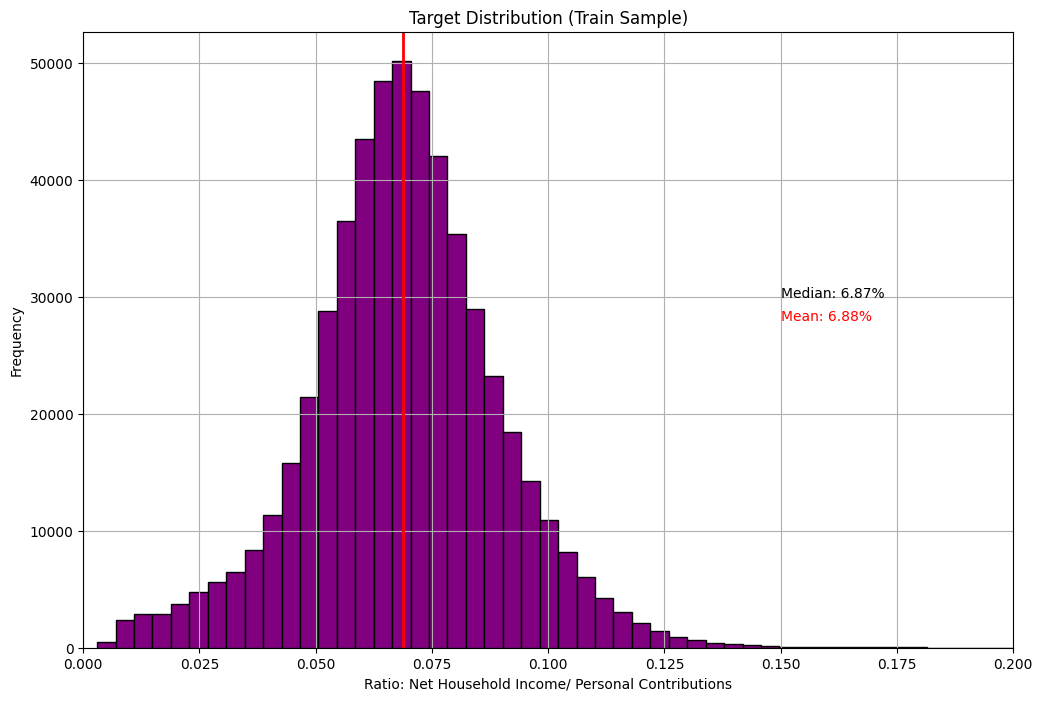

In [ ]:
y_train_red['TARGET'].to_pandas().hist(figsize = (12, 8), bins = 60, edgecolor = 'black', color = 'purple')
plt.title("Target Distribution (Train Sample)")
plt.xlabel("Ratio: Net Household Income/ Personal Contributions")
plt.ylabel("Frequency")
plt.xlim(0,.2)
plt.annotate(f"Median:{100*np.median(y_train_red['TARGET'].to_pandas()): .2f}%", xy=(.15,30000))
plt.annotate(f"Mean:{100*np.mean(y_train_red['TARGET'].to_pandas()): .2f}%", xy=(.15,28000), color = "red")
#plt.axvline(x=np.median(y_train['TARGET'].to_pandas()), linewidth=2)
plt.axvline(x=np.mean(y_train_red['TARGET'].to_pandas()), color ="red", linewidth=2)
plt.show()

# Modelling

## Elastic Net

In [ ]:
# Subsample 10% of the train set to help the model converge
X_validate, _, y_validate, _ = train_test_split(X_train_scaled, y_train_red, train_size=0.1, random_state=2025)

In [ ]:
# Find best hyperparameters
# Tune hyperparameters
elastic_net = ElasticNetCV(
    l1_ratio = np.linspace(0.1, 1.0, 10) ,
    alphas = [0.00001, 0.0001, 0.001, 0.01, 0.1, 0.5],
    cv=5,
    max_iter=10000,
    n_jobs=-1,
    verbose=1,
    tol=0.0001,
    random_state=2025
)

# Fit model
elastic_net.fit(X_validate, y_validate)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
......................................../Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.24117316245803178, tolerance: 0.0018287538806065393
  model = cd_fast.enet_coordinate_descent_gram(
./Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number

ElasticNetCV(alphas=[1e-05, 0.0001, 0.001, 0.01, 0.1, 0.5], cv=5,
             l1_ratio=array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
             max_iter=10000, n_jobs=-1, random_state=2025, verbose=1)

In [ ]:
# Get best parameters
# Get the best parameters
print(f"Best alpha: {elastic_net.alpha_}")
print(f"Best l1_ratio: {elastic_net.l1_ratio_}")

Best alpha: 1e-05
Best l1_ratio: 0.1


In [ ]:
# Fit the better model 
elastic_net_final = ElasticNet(
    alpha=elastic_net.alpha_,
    l1_ratio=elastic_net.l1_ratio_,
    max_iter=10000,
    tol=0.0001,
    random_state=2025
)

elastic_net_final.fit(X_train_scaled, y_train_red)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.637e+00, tolerance: 2.299e-02
  model = cd_fast.enet_coordinate_descent(


ElasticNet(alpha=1e-05, l1_ratio=0.1, max_iter=10000, random_state=2025)

In [ ]:
# Evaluate on test set 
# Predict on test set
y_pred = elastic_net_final.predict(X_test_scaled)

# Evaluation metrics
mse = mean_squared_error(y_test_red, y_pred)
rmse = root_mean_squared_error(y_test_red, y_pred)
mae = mean_absolute_error(y_test_red, y_pred)
r2 = r2_score(y_test_red, y_pred)

print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R² Score: {r2:.4f}")

Test MSE: 0.0002
Test RMSE: 0.0139
Test MAE: 0.0101
Test R² Score: 0.5389


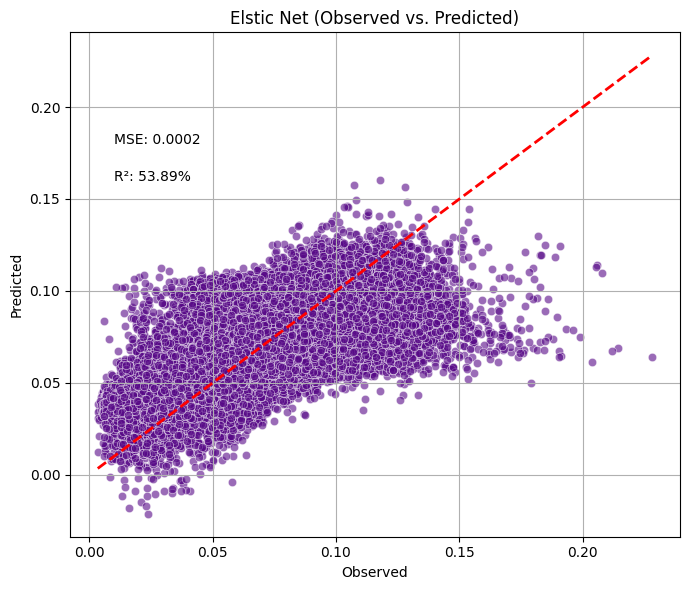

In [ ]:
# Convert y_test numPy array and flatten
y_test_flat = y_test_red.to_numpy().ravel()
y_pred_flat = y_pred.ravel()

# Now plot
plt.figure(figsize=(7, 6))
sns.set_palette(sns.color_palette(["#570987"]))
sns.scatterplot(x=y_test_flat, y=y_pred_flat, alpha=0.6)
plt.plot([y_test_flat.min(), y_test_flat.max()], [y_test_flat.min(), y_test_flat.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Elstic Net (Observed vs. Predicted)")
plt.annotate(f"R²:{r2*100: .2f}%", xy=(0.01,0.16), color = "black")
plt.annotate(f"MSE:{mse: .4f}", xy=(0.01,0.18), color = "black")
plt.grid(True)
plt.tight_layout()
plt.show()

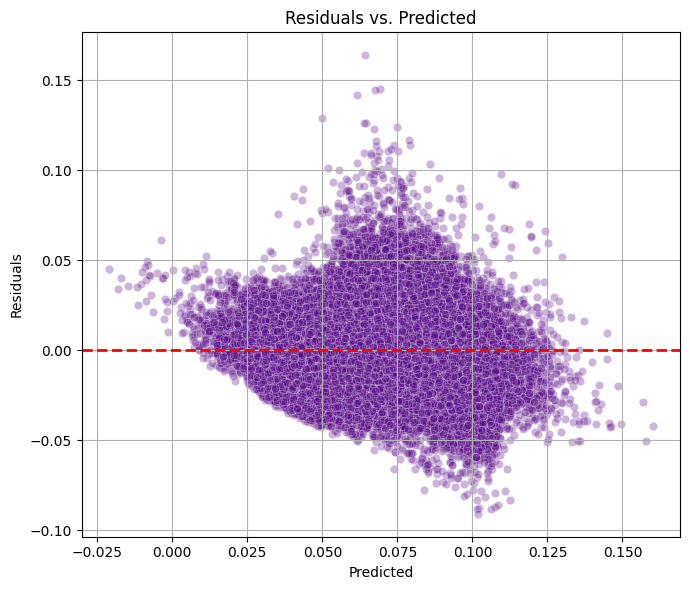

In [ ]:
residuals = y_test_flat - y_pred_flat

plt.figure(figsize=(7, 6))
sns.set_palette(sns.color_palette(["#570987"]))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Get coefficients 
coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': elastic_net_final.coef_
})

# Add absolute value column and sort by it (descending)
coef_df['abs_coefficient'] = np.abs(coef_df['coefficient'])
coef_df = coef_df.sort_values(by='abs_coefficient', ascending=False).drop(columns='abs_coefficient')

# Display top 10 most influential features
print("Most 10 Relevant coefficients:")
print(coef_df.head(10))
print("\nLess 10 Relevant coefficients:")
print(coef_df.tail(10))

Most 10 Relevant coefficients:
         feature  coefficient
42       HSHC005    -0.065277
5       HSHC001S     0.064160
301   ECYMTN3564     0.027137
4       HSHO001S    -0.018348
78   ECYHTY1FHNP    -0.016785
43       HSHC010     0.016038
9       HSPC001S    -0.013887
302  ECYMTN6585P    -0.013528
243   ECYMOTFREN     0.010914
132   ECYCDOOWNC     0.010729

Less 10 Relevant coefficients:
        feature  coefficient
83   ECYHTYN65A          0.0
60    ECYPTAPOP         -0.0
37      HSCS007         -0.0
279   ECYRIMOCE          0.0
209  ECYPOWINLF         -0.0
85   ECYMARHP15         -0.0
41      HSHC004          0.0
274   ECYRIMCAO          0.0
213  ECYPOWUSUL          0.0
89   ECYMARSING          0.0


In [ ]:
# Variables cleaned
coef_df[coef_df['coefficient']==0]

,feature,coefficient
214,ECYTRAHPL,-0.0
292,ECYHMA0_14,0.0
163,ECYPNIWIN,-0.0
169,ECYEDUUDBD,0.0
51,HSTR030,-0.0
109,ECYMOBMOV,0.0
152,ECYHNI6080,0.0
17,HSWH002S,-0.0
44,HSHC015,0.0
40,HSHC003,0.0


From the initial 303 varriables, the model shrinked to zero 27 of them.

In [ ]:
## Function to bootstrap MSE and  R2
def bootstrap_metrics(y_test, y_pred, n_bootstraps=100, significance=.05):
  np.random.seed(2025) # DO NOT DELETE
  lower = significance*100/ 2
  upper = 100 - (lower)
  # Get the accuracy and AUC scores for the test set
  mse = mean_squared_error(y_test.to_pandas(), y_pred)
  r2 = r2_score(y_test.to_pandas(), y_pred)

  # Create a bootstrap measurement for accuracy and AUC. We will use 100 bootstraps. Normally we would use 1000 or more.
  bootstrapped_mse = np.zeros(n_bootstraps)
  bootstrapped_r2 = np.zeros(n_bootstraps)

  for i in range(n_bootstraps):
      # Get the indices for the bootstrap sample
      idx = np.random.choice(len(y_test), len(y_test), replace=True)

      # Get the accuracy of the bootstrap sample
      bootstrapped_mse[i] = mean_squared_error(y_test.to_pandas().iloc[idx], y_pred[idx])

      # Get the AUC of the bootstrap sample
      bootstrapped_r2[i] = r2_score(y_test.to_pandas().iloc[idx], y_pred[idx])

  # Get the differences between the bootstrapped values and the original values
  mse_diff = bootstrapped_mse - mse
  r2_diff = bootstrapped_r2 - r2

  # Calculate the 95% confidence interval for the accuracy and AUC
  mse_ci = np.percentile(mse_diff, [lower, upper])
  r2_ci = np.percentile(r2_diff, [lower, upper])

  # Print the results. Centre the values around the original values.
  print(f"The 95% confidence interval for the MSE is [{(mse - mse_ci[1]):.5f}, {(mse - mse_ci[0]):.5f}]")
  print(f"The 95% confidence interval for the R2 is [{(r2 - r2_ci[1])*100:.5f}%, {(r2 - r2_ci[0])*100:.5f}%]")


In [ ]:
bootstrap_metrics(y_test_red, y_pred, n_bootstraps=10000, significance=.05)

The 95% confidence interval for the MSE is [0.00019, 0.00020]
The 95% confidence interval for the R2 is [53.55799%, 54.22140%]




We can observe that residuals follow a pattern, so the homoscedasticity assuption is violated. 
Elastic Net (like Ridge or Lasso) is a regularized linear regression. While it doesn't rely heavily on classical OLS assumptions for estimation, heteroscedasticity can still:

* Impact model interpretation: Coefficients may be less efficient (though regularization mitigates some of this).
* Affect predictive intervals: Confidence and prediction intervals may be misleading.
* Bias tests of significance: If you're doing hypothesis testing on coefficients (less common with Elastic Net), standard errors may be biased.

So while it's not a catastrophe, it's still a problem. 
Let's try to correct this issue by transforming the response.

In [ ]:
# Lets transform the answer to correct heteroscedastic residuals
y_validate_log = np.log1p(y_validate)

In [ ]:
# Fine best parametera 
elastic_net.fit(X_validate, y_validate_log)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
......................................../Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.05442707089245147, tolerance: 0.0015789616634841472
  model = cd_fast.enet_coordinate_descent_gram(
./Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number

ElasticNetCV(alphas=[1e-05, 0.0001, 0.001, 0.01, 0.1, 0.5], cv=5,
             l1_ratio=array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
             max_iter=10000, n_jobs=-1, random_state=2025, verbose=1)

In [ ]:
# Get best parameters
# Get the best parameters
print(f"Best alpha: {elastic_net.alpha_}")
print(f"Best l1_ratio: {elastic_net.l1_ratio_}")

Best alpha: 1e-05
Best l1_ratio: 0.1


In [ ]:
# Transform response 
y_train_log = np.log1p(y_train_red)

# Fit the better model 
elastic_net_final_2 = ElasticNet(
    alpha=elastic_net.alpha_,
    l1_ratio=elastic_net.l1_ratio_,
    max_iter=10000,
    tol=0.0001,
    random_state=2025
)

elastic_net_final_2.fit(X_train_scaled, y_train_log)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.197e+00, tolerance: 2.014e-02
  model = cd_fast.enet_coordinate_descent(


ElasticNet(alpha=1e-05, l1_ratio=0.1, max_iter=10000, random_state=2025)

In [ ]:
# Evaluate on test set 
# Predict on test set
y_pred_2 = np.expm1(elastic_net_final_2.predict(X_test_scaled))

# Evaluation metrics
mse = mean_squared_error(y_test_red, y_pred_2)
rmse = mean_squared_error(y_test_red, y_pred_2)
mae = mean_absolute_error(y_test_red, y_pred_2)
r2 = r2_score(y_test_red, y_pred_2)

print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R² Score: {r2:.4f}")

Test MSE: 0.0002
Test RMSE: 0.0002
Test MAE: 0.0102
Test R² Score: 0.5369


In [ ]:
# Convert y_test numPy array and flatten
y_test_flat2 = y_test_red.to_numpy().ravel()
y_pred_flat2 = y_pred_2.ravel()

# Now plot
plt.figure(figsize=(7, 6))
sns.set_palette(sns.color_palette(["#570987"]))
sns.scatterplot(x=y_test_flat2, y=y_pred_flat2, alpha=0.6)
plt.plot([y_test_flat2.min(), y_test_flat2.max()], [y_test_flat2.min(), y_test_flat2.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Elstic Net (Observed vs. Predicted)")
plt.annotate(f"R²:{r2*100: .2f}%", xy=(0.01,0.16), color = "black")
plt.annotate(f"MSE:{mse: .4f}", xy=(0.01,0.18), color = "black")
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'y_test_red' is not defined

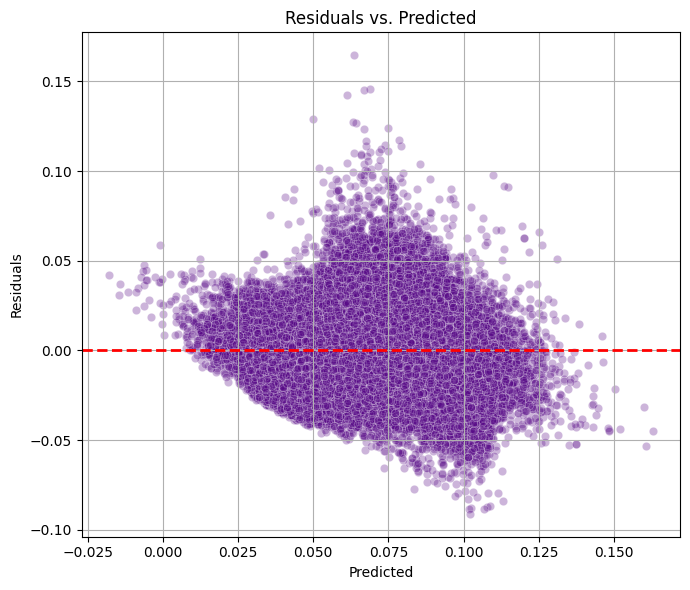

In [ ]:
# Convert y_test numPy array and flatten
y_pred_flat_2 = y_pred_2.ravel()

residuals = y_test_flat - y_pred_flat_2

plt.figure(figsize=(7, 6))
sns.set_palette(sns.color_palette(["#570987"]))
sns.scatterplot(x=y_pred_2, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

The transformation didn't help. However, heteroscedasticity can distort inference (standard errors, confidence intervals), that we don't rewuire for this course work, moreover

Trees-based models like XGBoost, Random Forest, or Gradient Boosting:
* Don’t assume constant variance
* Handle heteroscedasticity naturally

This is the second part of the supervised models. Let's keep the first model and compare with the XGboost  one. 

## XGBoost model

We apply the same data treatment to help the XGBoost model converge.

In [ ]:
# Subsample 10% of the train set to help the model converge
X_validate, X_val_90, y_validate, y_val_90 = train_test_split(X_train_scaled, y_train_red, train_size=0.1, random_state=2025)


In [ ]:
# Get another subsample not included in the validate set
X_validate_2, _, y_validate_2, _ = train_test_split(X_val_90, y_val_90, train_size=0.1, random_state=2025)

In [ ]:
    # Find best hyperparameters

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=2025,
    n_jobs=-1,
    verbosity=1, 
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,      # L1
    reg_lambda=5,     # L2
    early_stopping_rounds=10
)

param_grid = {
    'n_estimators': [ 700, 750, 800],
    'max_depth': [5, 10, 15], # Maximum depth of a tree
    'learning_rate': [0.1, 0.25, 0.5], # Step size shrinkage used in update to prevent overfitting.
# 'subsample': [0.6, 0.8, 1.0], # Subsample ratio of the training instances. Setting it to 0.5 means that XGBoost would randomly sample half of the training data prior to growing trees. and this will prevent overfitting. Subsampling will occur once in every boosting iteration.
# 'colsample_bytree': [0.6, 0.8, 1.0], # Specify the fraction of columns to be subsampled
# 'reg_alpha': [0.1, .5, .75, 1],  # L1 regularization
# 'reg_lambda': [3, 5,10]   # L2 regularization
}


grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Use early stopping to speed up each model fit
#xgb_model.set_params(early_stopping_rounds=10)

# Fit the model
grid_search.fit(
    X_validate, y_validate,
    eval_set=[(X_validate_2, y_validate_2)],  # Use held-out set!
    verbose=True
)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
[0]	validation_0-rmse:0.02031
[1]	validation_0-rmse:0.01995
[2]	validation_0-rmse:0.01964
[0]	validation_0-rmse:0.02031
[3]	validation_0-rmse:0.01932
[1]	validation_0-rmse:0.01995
[4]	validation_0-rmse:0.01902
[2]	validation_0-rmse:0.01963
[5]	validation_0-rmse:0.01875
[0]	validation_0-rmse:0.02031
[3]	validation_0-rmse:0.01932
[6]	validation_0-rmse:0.01849
[1]	validation_0-rmse:0.01995
[4]	validation_0-rmse:0.01902
[7]	validation_0-rmse:0.01825
[2]	validation_0-rmse:0.01961
[5]	validation_0-rmse:0.01874
[3]	validation_0-rmse:0.01930
[8]	validation_0-rmse:0.01803
[6]	validation_0-rmse:0.01848
[4]	validation_0-rmse:0.01902
[9]	validation_0-rmse:0.01783
[7]	validation_0-rmse:0.01824
[5]	validation_0-rmse:0.01875
[10]	validation_0-rmse:0.01763
[8]	validation_0-rmse:0.01802
[11]	validation_0-rmse:0.01744
[6]	validation_0-rmse:0.01848
[9]	validation_0-rmse:0.01782
[7]	validation_0-rmse:0.01825
[12]	validation_0-rmse:0.01727
[8]	v

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.8,
                                    device=None, early_stopping_rounds=10,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    le...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1, 0.25],
                         'max_depth': [2, 3, 5],
                         'n_estimators': [600, 650, 700]},
             scoring='neg_mean_squared_error', verbose=1)

In [ ]:
print("Best parameters:",grid_search.best_params_)

Best parameters: {'learning_rate': 0.25, 'max_depth': 5, 'n_estimators': 700}


In [ ]:
# {'learning_rate': 0.25, 'max_depth': 5, 'n_estimators': 700}
xgb_best = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=2025,
    n_jobs=-1,
    verbosity=1, 
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,      # L1
    reg_lambda=5,     # L2
    learning_rate= 0.25, 
    max_depth = 5, 
    n_estimators= 700

)

# Fit model
xgb_best.fit(X_train_scaled, y_train_red)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.25, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=700,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# Predict
y_pred_xgb = xgb_best.predict(X_test_scaled)

# Evaluate
mse = mean_squared_error(y_test_red, y_pred_xgb)
rmse = root_mean_squared_error(y_test_red, y_pred_xgb)
mae = mean_absolute_error(y_test_red, y_pred_xgb)
r2 = r2_score(y_test_red, y_pred_xgb)
print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R2", r2)

Test MSE: 8.516234811395407e-05
Test RMSE: 0.00922834500670433
Test MAE: 0.006739629898220301
Test R2 0.7972299456596375


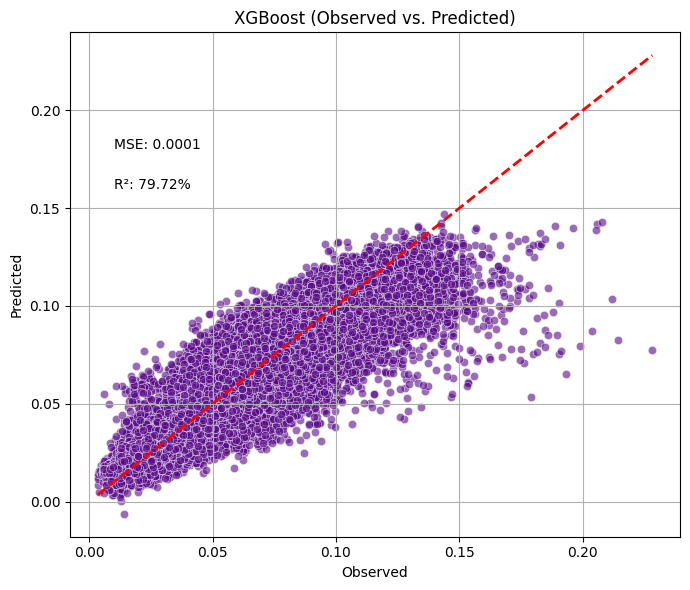

In [ ]:
# Convert y_test numPy array and flatten
y_test_flat = y_test_red.to_numpy().ravel()
y_pred_flat = y_pred_xgb.ravel()

# Now plot
plt.figure(figsize=(7, 6))
sns.set_palette(sns.color_palette(["#570987"]))
sns.scatterplot(x=y_test_flat, y=y_pred_flat, alpha=0.6)
plt.plot([y_test_flat.min(), y_test_flat.max()], [y_test_flat.min(), y_test_flat.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("XGBoost (Observed vs. Predicted)")
plt.annotate(f"R²:{r2*100: .2f}%", xy=(0.01,0.16), color = "black")
plt.annotate(f"MSE:{mse: .4f}", xy=(0.01,0.18), color = "black")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
bootstrap_metrics(y_test_red, y_pred_xgb, n_bootstraps=10000, significance=.05)

The 95% confidence interval for the MSE is [0.00008, 0.00009]
The 95% confidence interval for the R2 is [79.50835%, 79.94106%]


**Elastic Net**

The 95% confidence interval for the MSE is [0.00019, 0.00020]

The 95% confidence interval for the R2 is [53.55799%, 54.22140%]

As we can observe, the metrics are better for the XGBoost model and the CI are thigher.

## Results interpretation

In [ ]:
# Use the best-tuned XGBoost model from
data = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Apply SHAP to the best XGBoost model
explainer = shap.TreeExplainer(xgb_best,data = data )

# Applies model to the full dataset.
shap_values = explainer.shap_values(data, check_additivity=False)

100%|===================| 232695/232696 [52:49<00:00]        

/var/folders/qh/8xvsb7ss1t9043zm17zm38x40000gn/T/ipykernel_35069/370458187.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values,  data, show=False)


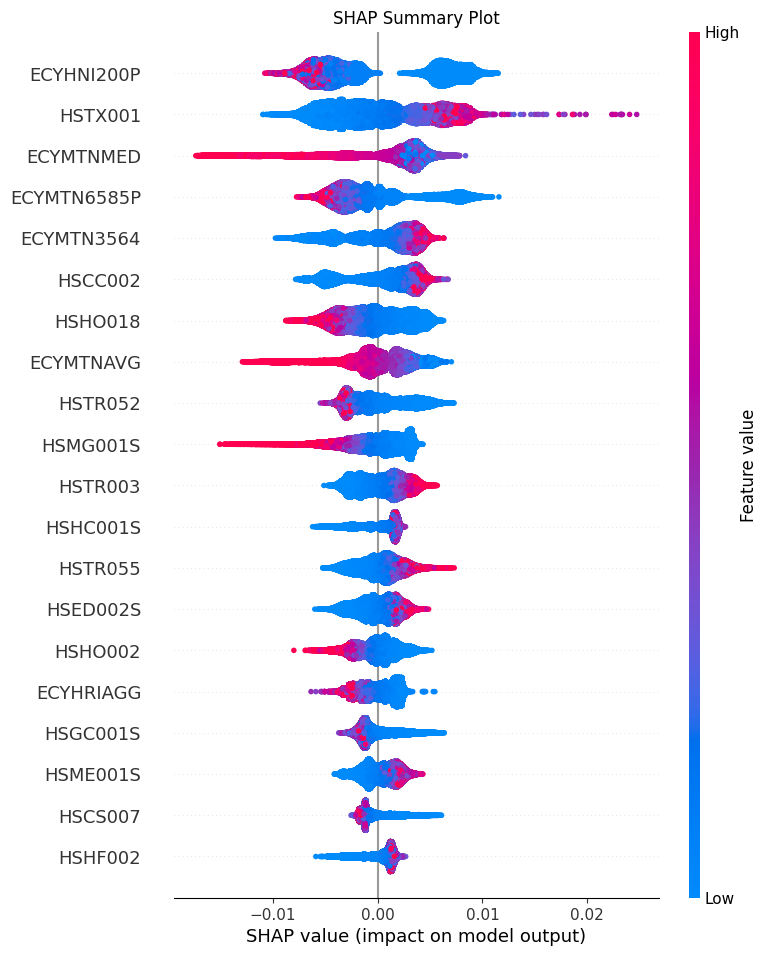

In [ ]:
# Generate SHAP Summary Plot
shap.summary_plot(shap_values,  data, show=False)

plt.title('SHAP Summary Plot')
plt.savefig('ShapSummaryPlot.pdf', dpi=300, bbox_inches='tight')
plt.show()  

**5 Most relevant variables in XGBoost**

* ECYHNI200P Household Income \$200,000 or Over (Current Year $): The lower the income over \$200,000, the greater proportion on retirement premiums over income. People with lower incomes are more concerned about risks. 

* HSTX001  Income tax: The less taxes paid, the lower ratios. It suggest that people with lower income tend to contribute less to insurance and retirement, or their policies are "simplier" (less benefits).

* ECYMTNMED Median Maintainer Age: Older maintainers then to contribute less.

* ECYMTN6585P Maintainers 65 or Over: Households with less number of maintainers over 65 years old, tend to expend more in insurance and retirement. 

* ECYMTN3564 Maintainers 35 To 64: Households with more number of maintainers between 35 and 64 years old, tend to expend more in insurance and retirement.

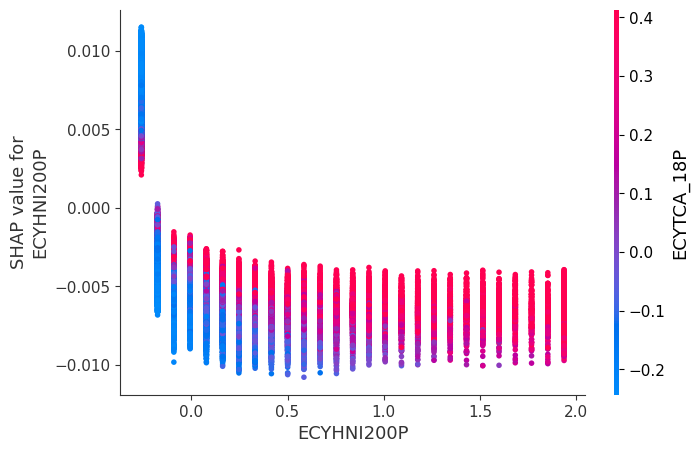

In [ ]:
shap.dependence_plot("ECYHNI200P",                          # The variable to study
                     shap_values,                       # The Shapley values.
                     data, # The training sample
                     show=False)                        # Whether to print the model or not

plt.savefig('ShapEmploy_ECYHNI200P.pdf', dpi=300, bbox_inches='tight')
plt.show()

Variables:

* ECYHNI200P Household Income \$200,000 Or Over (Current Year $)
* ECYTCA_18P Citizens 18 Or Older

As ECYHNI200P increases (moving right), the contribution becomes increasingly negative before stabilizing. 

Higher values of ECYHNI200P generally predict lower insurance/retirement-to-income ratios

When ECYTCA_18P is high (red), the negative impact of ECYHNI200P is somewhat moderated compared to when ECYTCA_18P is low 

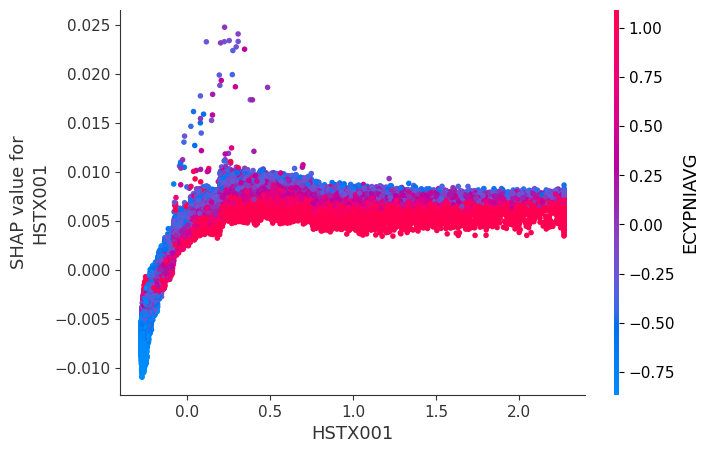

In [ ]:
shap.dependence_plot("HSTX001",                          # The variable to study
                     shap_values,                       # The Shapley values.
                     data, # The training sample
                     show=False)                        # Whether to print the model or not

plt.savefig('ShapEmploy_HSTX001.pdf', dpi=300, bbox_inches='tight')
plt.show()

Variables:

* HSTX001 Income tax
* ECYPNIAVG Average Income ($)

HSTX001 has a positive influence on predictions, particularly in the [0, 0.5] range.

Its influence saturates beyond ~0.5.

Interaction with ECYPNIAVG is meaningful: when both are high, the prediction is even more positively influenced.

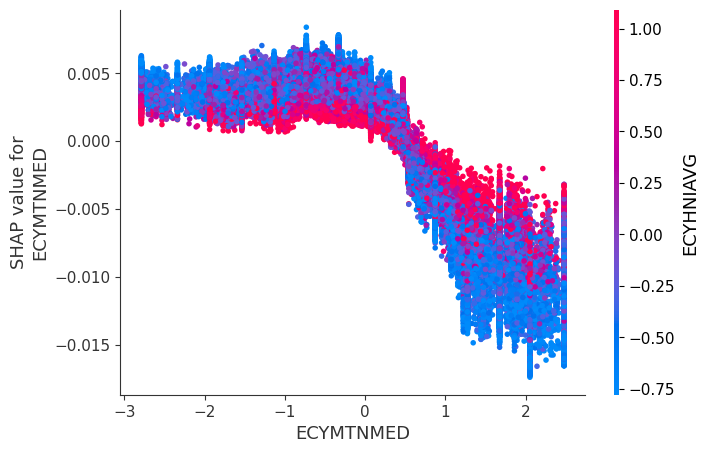

In [ ]:
shap.dependence_plot("ECYMTNMED",                          # The variable to study
                     shap_values,                       # The Shapley values.
                     data, # The training sample
                     show=False)                        # Whether to print the model or not

plt.savefig('ShapEmploy_ECYMTNMED.pdf', dpi=300, bbox_inches='tight')
plt.show()

Variables:

* ECYMTNMED Median Maintainer Age

* ECYHNIAVG Average Household Income (Current Year $)

As ECYMTNMED increases beyond 0, households tend to allocate a smaller proportion of their income to insurance and retirement savings.

Households with lower average income are more sensitive to changes in ECYMTNMED when determining their insurance/retirement spending ratio.

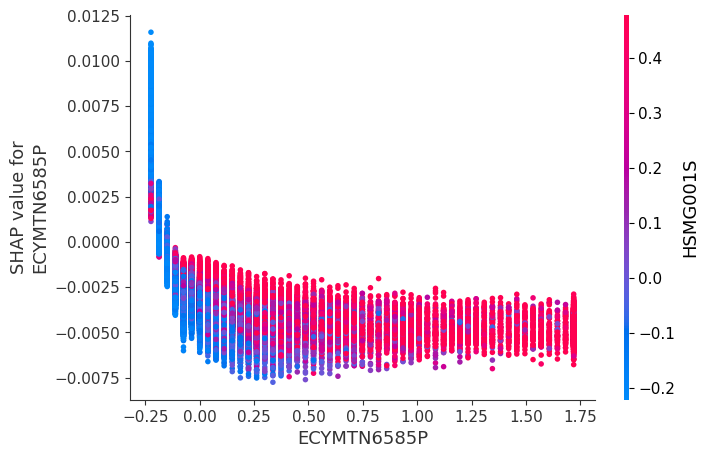

In [ ]:
shap.dependence_plot("ECYMTN6585P",                          # The variable to study
                     shap_values,                       # The Shapley values.
                     data, # The training sample
                     show=False)                        # Whether to print the model or not

plt.savefig('ShapEmploy_ECYMTN6585P.pdf', dpi=300, bbox_inches='tight')
plt.show()

Variables:
* ECYMTN6585P Maintainers 65 or Over
* HSMG001S Total money gifts, contributions and support payments

Household with less number of maintainers with 65 years old or over, likely allocate a higher proportion of income to insurance/retirement. And they tend to  expend more on gifts or contributions.


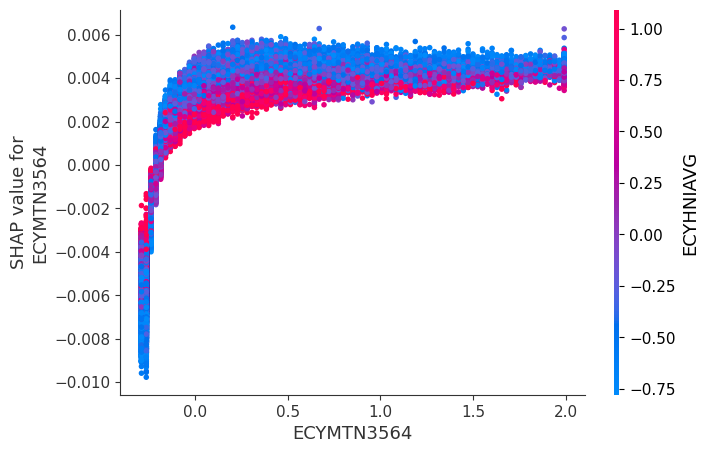

In [ ]:
shap.dependence_plot("ECYMTN3564",                          # The variable to study
                     shap_values,                       # The Shapley values.
                     data, # The training sample
                     show=False)                        # Whether to print the model or not

plt.savefig('ShapEmploy_ECYMTN3564.pdf', dpi=300, bbox_inches='tight')
plt.show()

Variables: 

* ECYMTN3564 Maintainers 35 To 64

* ECYHNIAVG Average Household Income (Current Year $)

Households with more maintainers between 35 and 64 years old with higher average household income tend to expen more on insurance and/or retirement.

**5 Most relevant variables in both models**

**XGBoost**

* ECYHNI200P Household Income \$200,000 or Over (Current Year $)
* HSTX001  Income tax
* ECYMTNMED Median Maintainer Age
* ECYMTN6585P Maintainers 65 or Over (it is the 8 th more important vaiable in the ElasticNet model)
* ECYMTN3564 Maintainers 35 To 64 (it is the 3 th more important vaiable in the ElasticNet model)

**Elatic Net**
* HSHC005  Health care services
* HSHC001S Health care (it is the 12 th more important vaiable in the XGBoost model)
* ECYMTN3564  Maintainers 35 To 64  (also relevant in XGB)
* HSHO001S   Household operation
* ECYHTY1FHNP  One-Family Households Without Additional Persons